In [1]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
from matplotlib.ticker import ScalarFormatter
import brainsignals.plotting_convention as pc

plt.rcParams.update({
    "figure.dpi": 600,
    "figure.figsize": (6, 2.5),
    "font.size": 8,
    "mathtext.fontset": "stix"
})

In [2]:
file_path = '/home/tone/work/celltype_ES/CellTypeDependenceElStim/simulations/sim_results/plot_imem_data_ideal.npy'
imem_data = np.load(file_path, allow_pickle=True).item()


In [3]:
# Make subset data dictionary for Im plots
target_freqs = [10, 100, 1000]

scatter_imem_data = {}

for cell_name, cell_data in imem_data.items():
    freqs = np.array(cell_data['freqs'])
    print(freqs)
    # Find indices corresponding to 10, 100, and 1000 Hz
    freq_indices = [np.argmin(np.abs(freqs - f)) for f in target_freqs]
    
    # Extract subsets
    imem_amps_subset = np.array(cell_data['imem_amps'])[:, freq_indices].tolist()
    imem_phases_subset = np.array(cell_data['imem_phases'])[:, freq_indices].tolist()
    pos_avg_subset = [cell_data['positive_avg_imem_pos'][i] for i in freq_indices]
    neg_avg_subset = [cell_data['negative_avg_imem_pos'][i] for i in freq_indices]
    cdm_pos_subset = [cell_data['cdm_pos'][i] for i in freq_indices]
    cdm_neg_subset = [cell_data['cdm_neg'][i] for i in freq_indices]
    
    # Build new dictionary for this cell
    scatter_imem_data[cell_name] = {
        'freqs': [freqs[i] for i in freq_indices],
        'x': cell_data['x'],
        'z': cell_data['z'],
        'totnsegs': cell_data['totnsegs'],
        'tvec': cell_data['tvec'],
        'imem_amps': imem_amps_subset,
        'imem_phases': imem_phases_subset,
        'cdm_pos': cdm_pos_subset,
        'cdm_neg': cdm_neg_subset
    }

[   1    5   10   50  100  500 1000]
[   1    5   10   50  100  500 1000]
[   1    5   10   50  100  500 1000]
[   1    5   10   50  100  500 1000]


In [4]:
imem_data['BL_-500_UL_1000_SD_20_DD_2'].keys()

dict_keys(['freqs', 'x', 'z', 'totnsegs', 'area', 'tvec', 'imem_amps', 'imem_phases', 'positive_avg_imem_pos', 'negative_avg_imem_pos', 'input_amps', 'input_phases', 'cdm', 'cdm_phases', 'cdm_pos', 'cdm_pos_phases', 'cdm_neg', 'cdm_neg_phases'])

In [5]:
def plot_imem_ideal(subset_imem_data, full_imem_data, xlim1 = (None, -0.002), xlim2 = (-4e-5, None)):
    left_cells = subset_imem_data
    right_cells = full_imem_data

    unique_cells = list(left_cells.keys())
    num_cells = len(unique_cells)
    if num_cells == 0:
        print("No cells to plot.")
        return

    # --- Figure setup ---
    fig = plt.figure(figsize=(10, 3 * num_cells))
    main_gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.8, 1], wspace=0.4)

    # --- LEFT PANEL (subset_imem_data with broken axis) ---
    gs_left = gridspec.GridSpecFromSubplotSpec(
        num_cells, 3, subplot_spec=main_gs[0, 0], width_ratios=[1, 1.2, 1.2], wspace=0.2, hspace=0.5
    )

    axs_left_panel = {}
    for i, label in enumerate(unique_cells):
        axs_left_panel[label] = {
            'morph': fig.add_subplot(gs_left[i, 0]),
            'imem_left': fig.add_subplot(gs_left[i, 1]),
            'imem_right': fig.add_subplot(gs_left[i, 2], sharey=fig.axes[-1] if i > 0 else None),
        }

    colors_neurons = ['salmon', 'deepskyblue']
    colors_pz = ['firebrick', 'darkblue']

    # ==================  MAIN LOOP OVER CELLS ===================================
    
    for i, (label, ax_dict) in enumerate(axs_left_panel.items()):

        # ---------------- Load cell data ----------------
        cell_data = left_cells[label]
        x = np.array(cell_data['x'])
        z = np.array(cell_data['z'])
        totnsegs = cell_data['totnsegs']
        freqs = np.array(cell_data['freqs'])
        imem_amps = np.array(cell_data['imem_amps'])
        imem_phases = np.array(cell_data['imem_phases'])
        z_coords = z.mean(axis=-1)

        # ------------------------------------------------------------
        #                 A: MORPHOLOGY PLOT
        # ------------------------------------------------------------
        ax_morph = ax_dict['morph']
        color = colors_neurons[i % len(colors_neurons)]
        for idx in range(totnsegs):
            ax_morph.plot(x[idx], z[idx], c=color, lw=2)
        ax_morph.plot(x.mean(axis=-1)[0], z.mean(axis=-1)[0], 'o', color='black', markersize=4)
        name = 'long neuron' if 'BL_-500_UL_1000' in label else 'short neuron'
        ax_morph.set_xlim(-np.max(z) * 0.3, np.max(z) * 0.3)
        ax_morph.set_title(name, fontsize=10, x=0.5, y=1.06)
        ax_morph.set_aspect('equal')
        ax_morph.set_xticks([])
        ax_morph.set_frame_on(False)

        

        # ------------------------------------------------------------
        #                B: SCATTER PLOTS WITH PHASE
        # ------------------------------------------------------------
        
        # Compute time of maximal inward soma Im 
        soma_amps = imem_amps[0]        # shape (3 freqs)
        soma_phases = imem_phases[0]

        t_max_dict = {}

        for f_idx, f in enumerate(freqs):
            A0 = soma_amps[f_idx]
            phi0 = soma_phases[f_idx]

            # time at the negative peak (inward Im)
            t_min = (3*np.pi/2 - phi0) / (2*np.pi*f)

            while t_min < 0:
                t_min += 1.0/f

            t_max_dict[f] = t_min
        
        print(t_max_dict)

        ax_imem_left = ax_dict['imem_left']
        ax_imem_right = ax_dict['imem_right']
        colors_imem = ['tab:purple', 'tab:orange', 'tab:green']

        for f_idx, f in enumerate(freqs):

            chosen_t = t_max_dict[f]
            z_imem_map = defaultdict(float)

            # Compute instantaneous Im(t)
            for seg_idx in range(totnsegs):
                amp = imem_amps[seg_idx][f_idx]
                phi = imem_phases[seg_idx][f_idx]
                im_t = amp * np.sin(2*np.pi*f*chosen_t + phi)
                z_imem_map[z_coords[seg_idx]] += im_t

            z_vals = list(z_imem_map.keys())
            im_vals = list(z_imem_map.values())

            # keep your marker rules
            marker, markersize, alpha = (
                ('o', 25, 1) if f == 10 else
                ('x', 10, 1) if f == 100 else
                ('^', 10, 1)
            )

            ax_imem_left.scatter(im_vals, z_vals,
                                 color=colors_imem[f_idx],
                                 alpha=alpha,
                                 marker=marker,
                                 s=markersize)

            ax_imem_right.scatter(im_vals, z_vals,
                                  color=colors_imem[f_idx],
                                  alpha=alpha,
                                  marker=marker,
                                  s=markersize,
                                  label=f'{int(f)} Hz')

        ax_imem_right.axvline(0, color = 'black', linestyle = ':')

        # ------------------AXIS FORMATTING------------------------
        ax_imem_left.set_xlim(xlim1)
        ax_imem_right.set_xlim(xlim2)

        # Left 
        ax_imem_left.spines['right'].set_visible(False)
        ax_imem_left.yaxis.tick_left()
        ax_imem_left.set_ylabel('$z$ [µm]')
        ax_imem_left.tick_params(labelleft=True)

        fmt_left = ScalarFormatter(useMathText=True)
        fmt_left.set_powerlimits((-2, 2))
        ax_imem_left.ticklabel_format(style='sci', axis='x', scilimits=(-2, 2))
        ax_imem_left.xaxis.set_major_formatter(fmt_left)

        # Right
        ax_imem_right.spines['left'].set_visible(False)
        ax_imem_right.yaxis.set_visible(False)
        ax_imem_right.yaxis.set_label_position('right')

        fmt_right = ScalarFormatter(useMathText=True)
        fmt_right.set_powerlimits((-2, 2))
        ax_imem_right.ticklabel_format(style='sci', axis='x', scilimits=(-2, 2))
        ax_imem_right.xaxis.set_major_formatter(fmt_right)

        # Diagonal break markers
        d = .015
        kwargs = dict(transform=ax_imem_left.transAxes, color='k', clip_on=False)
        ax_imem_left.plot((1 - d, 1 + d), (-d, +d), **kwargs)
        ax_imem_left.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

        kwargs.update(transform=ax_imem_right.transAxes)
        ax_imem_right.plot((-d, +d), (-d, +d), **kwargs)
        ax_imem_right.plot((-d, +d), (1 - d, 1 + d), **kwargs)

        if i == 0:
            ax_imem_right.legend(loc='best', fontsize='small')

    # Shared x-label
    fig.text(0.4, -0.0, '$I_\\mathrm{m}(t=t_{\\min})$ [nA]', ha='center', fontsize=10)

    # ------------------------------------------------------------
    #              C: AVG IMEM POSSITION
    # ------------------------------------------------------------
    gs_right = gridspec.GridSpecFromSubplotSpec(
        num_cells, 1, subplot_spec=main_gs[0, 1], hspace=0.5
    )

    for i, label in enumerate(unique_cells):
        ax = fig.add_subplot(gs_right[i, 0])
        cell_data = right_cells[label]

        freqs = np.array(cell_data['freqs'])
        pos_avg = np.array(cell_data['positive_avg_imem_pos'])
        neg_avg = np.array(cell_data['negative_avg_imem_pos'])

        name = 'long neuron' if 'BL_-500_UL_1000' in label else 'short neuron'
        color = colors_neurons[0] if 'Long' in name else colors_neurons[1]

        ax.axhline(0, color = 'dimgray', linestyle = (0, (6,1)), linewidth=0.8)

        ax.plot(freqs, pos_avg, 'x:', color=color, label='$\\lambda_\\mathrm{AC}$ above', markersize=4)
        ax.plot(freqs, neg_avg, 'v--', color=color, label='$\\lambda_\\mathrm{AC}$ below', markersize=4)

        ax.set_xscale('log')
        ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.8)
        ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.8)
        #ax.grid(True, ls='--', alpha=0.6)
        lam_ylim = 1.3* max(np.max(pos_avg), np.max(np.abs(neg_avg)))
        ax.set_ylim(-lam_ylim, lam_ylim)
        ax.set_title(name, fontsize=10)
        ax.set_ylabel('$\\lambda_\\mathrm{AC}$ [µm]', fontsize=11, color=colors_neurons[i])
        #ax.legend(fontsize='x-small', loc='best')
        ax.tick_params(axis='y', labelcolor=colors_neurons[i])

        ax2 = ax.twinx()

        frequencies = cell_data['freqs']
        input_phases = cell_data['input_phases']
        cdm_amps = cell_data['cdm']
        cdm_phases = cell_data['cdm_phases']
        cdm_amps_up = cell_data['cdm_pos']
        cdm_phases_up = cell_data['cdm_pos_phases']
        cdm_ams_down = cell_data['cdm_neg']
        cdm_phases_down = cell_data['cdm_neg_phases']

        cdm_max_values = []
        cdm_values_pos = []
        cdm_values_neg = []
        for f_idx, f in enumerate(frequencies):
            cdm_amp = cdm_amps[f_idx]
            cdm_phase = cdm_phases[f_idx]
            
            t_max_cdm = ( np.pi/2 - cdm_phase)/(2*np.pi*f)
            print(t_max_cdm)

            cdm_max_value = cdm_amp * np.sin(2*np.pi*f*t_max_cdm + cdm_phase)
            cdm_max_values.append(cdm_max_value)

            cdm_pos_amp = cdm_amps_up[f_idx]
            cdm_pos_phase = cdm_phases_up[f_idx]
            cdm_value_pos = cdm_pos_amp * np.sin(2*np.pi*f*t_max_cdm + cdm_phase)
            cdm_values_pos.append(cdm_value_pos)

            cdm_neg_amp = -cdm_ams_down[f_idx]
            cdm_neg_phase = cdm_phases_down[f_idx]
            cdm_value_neg = cdm_neg_amp * np.sin(2*np.pi*f*t_max_cdm + cdm_phase)
            cdm_values_neg.append(cdm_value_neg)

        ax2.plot(freqs, cdm_max_values, '-', color=colors_pz[i], label=r'$p_z$ total', markersize=4)
        ax2.plot(freqs, cdm_values_pos, 'x:', color=colors_pz[i], label=r'$p_z$ above', markersize=4)
        ax2.plot(freqs, cdm_values_neg, 'v--', color=colors_pz[i], label=r'$p_z$ below', markersize=4)
        print(label, freqs, cdm_max_values)
        # ax2.plot(freqs, cdm_amps, '-', color='black', label='$p_z$ Tot', markersize=4)
        # ax2.plot(freqs, cdm_amps_up, 'x:', color='black', label='$p_z$ Below', markersize=4)
        # ax2.plot(freqs, -np.array(cdm_ams_down), 'v--', color='black', label='$p_z$ Below', markersize=4)

        ax2.set_ylabel(r'$p_z$ [nA$\cdot$µm]', fontsize=11, color=colors_pz[i])
        ax2.tick_params(axis='y', labelcolor=colors_pz[i])
        cdm_ylim = 1.3* max(np.max(cdm_values_pos), np.max(cdm_values_neg))
        ax2.set_ylim(-cdm_ylim, cdm_ylim)
        #ax2.legend(fontsize='x-small', loc='best')

        # ==== Combined legend for both axes ====
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()

        combined_lines = lines1 + lines2
        combined_labels = labels1 + labels2

        ax.legend(
            combined_lines,
            combined_labels,
            fontsize=6,
            loc='lower right',
            frameon=True,
            ncol = 2,
        )

    fig.text(0.77, -0.0, 'frequency [Hz]', ha='center', fontsize=10)

    # ===== Panel labels =====
    fig.text(0.1, 0.96, 'A', fontsize=12, fontweight='bold')
    fig.text(0.21, 0.96, 'B', fontsize=12, fontweight='bold')
    fig.text(0.62, 0.96, 'C', fontsize=12, fontweight='bold')

    fig.savefig("fig6_i.pdf",
                bbox_inches='tight')
    plt.show()


{np.int64(10): np.float64(0.0835860544712093), np.int64(100): np.float64(0.006658292827541756), np.int64(1000): np.float64(0.0009428589615257962)}
{np.int64(10): np.float64(0.05397432022782202), np.int64(100): np.float64(0.007155219195617463), np.int64(1000): np.float64(0.0010955401939150564)}
{np.int64(10): np.float64(0.05397910359190025), np.int64(100): np.float64(0.011039956801291993), np.int64(1000): np.float64(0.0008717565070923733)}
{np.int64(10): np.float64(0.11847129374738856), np.int64(100): np.float64(0.003950193375901453), np.int64(1000): np.float64(0.0008090491723768923)}
-0.11491837856383608
0.13642867416338983
-0.009914031222783363
-0.0009790109321724026
-0.00011365830474289875
0.0004945534124920658
-0.00020042869629965595
BL_-500_UL_1000_SD_20_DD_2 [   1    5   10   50  100  500 1000] [np.float64(0.8527476142045303), np.float64(0.8392065739616368), np.float64(0.8005244450685086), np.float64(0.38884527022762316), np.float64(0.18564693993856152), np.float64(0.0095232810109

IndexError: list index out of range

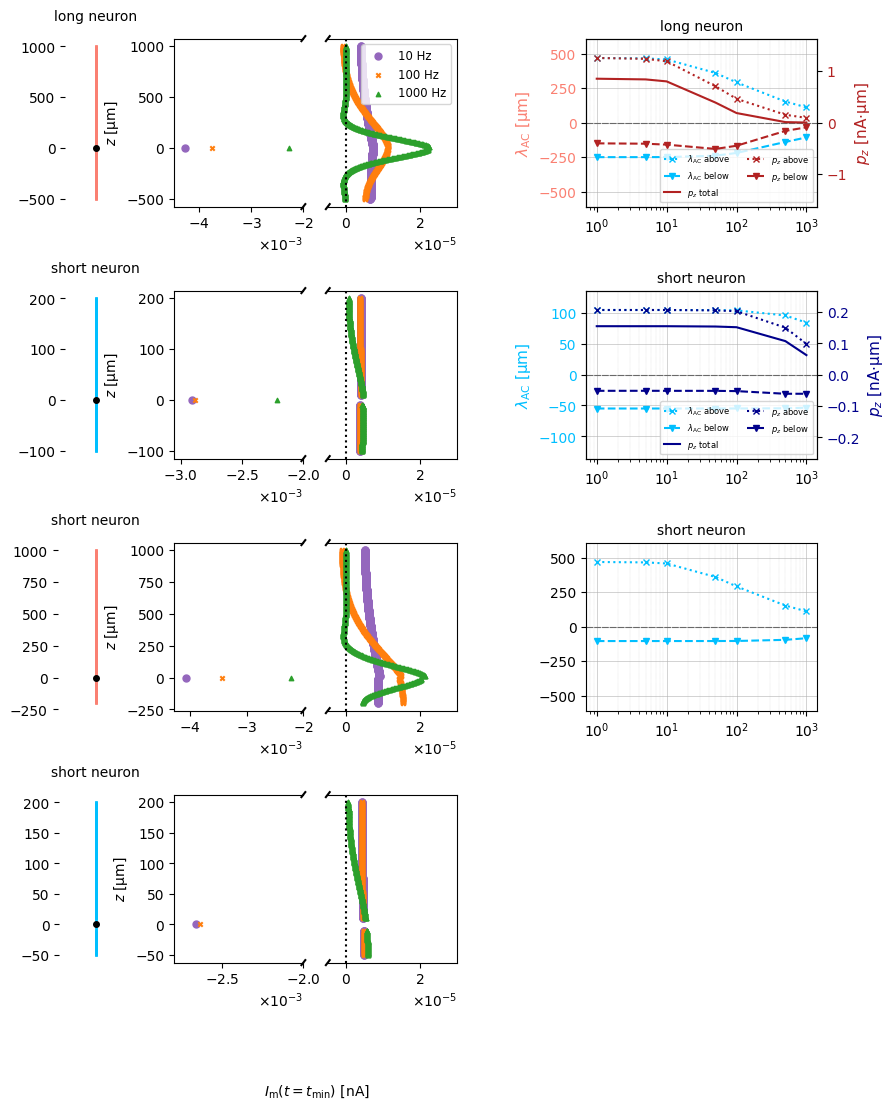

In [6]:
plot_imem_ideal(scatter_imem_data, imem_data, xlim1 = (None, -0.002), xlim2 = (-5e-6, 3e-5))

# t_max p_z

In [7]:
def plot_imem_ideal(
        subset_imem_data,
        full_imem_data,
        xlim1=(None, -0.002),
        xlim2=(-4e-5, -1e-6),
        xlim3=(-1e-6, None)
    ):

    left_cells = subset_imem_data
    right_cells = full_imem_data

    unique_cells = list(left_cells.keys())
    num_cells = len(unique_cells)
    if num_cells == 0:
        print("No cells to plot.")
        return

    # ========================= FIGURE SETUP ==============================
    fig = plt.figure(figsize=(11, 3 * num_cells))
    main_gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.8, 1], wspace=0.3)

    # -- LEFT PANEL: morphology + 3-way broken Im(t)
    gs_left = gridspec.GridSpecFromSubplotSpec(
        num_cells, 4, subplot_spec=main_gs[0, 0],
        width_ratios=[1, 1.2, 1.2, 1.2],
        wspace=0.3, hspace=0.5
    )

    axs_left_panel = {}

    for i, label in enumerate(unique_cells):
        ax_left = fig.add_subplot(gs_left[i, 1])
        ax_mid  = fig.add_subplot(gs_left[i, 2], sharey=ax_left)
        ax_right = fig.add_subplot(gs_left[i, 3], sharey=ax_left)

        axs_left_panel[label] = {
            'morph': fig.add_subplot(gs_left[i, 0]),
            'imem_left': ax_left,
            'imem_mid': ax_mid,
            'imem_right': ax_right,
        }

    colors_neurons = ['salmon', 'deepskyblue']
    colors_pz = ['firebrick', 'darkblue']
    colors_imem = ['tab:purple', 'tab:orange', 'tab:green']

    # ======================= MAIN CELL LOOP ==============================
    for i, (label, ax_dict) in enumerate(axs_left_panel.items()):

        # --------------------------- LOAD DATA ----------------------------
        cell_data = left_cells[label]
        x = np.array(cell_data['x'])
        z = np.array(cell_data['z'])
        totnsegs = cell_data['totnsegs']
        freqs = np.array(cell_data['freqs'])
        imem_amps = np.array(cell_data['imem_amps'])
        imem_phases = np.array(cell_data['imem_phases'])
        z_coords = z.mean(axis=-1)

        # ----------------------- A: MORPHOLOGY ---------------------------
        ax_m = ax_dict['morph']
        col = colors_neurons[i % len(colors_neurons)]

        for idx in range(totnsegs):
            ax_m.plot(x[idx], z[idx], c=col, lw=2)

        ax_m.plot(x.mean(axis=-1)[0], z.mean(axis=-1)[0], 'o', color='black', markersize=4)

        name = 'Long neuron' if 'BL_-500_UL_1000' in label else 'Short neuron'

        ax_m.set_xlim(-np.max(z) * 0.3, np.max(z) * 0.3)
        ax_m.set_title(name, fontsize=10, x=0.5, y=1.06)
        ax_m.set_aspect('equal')
        ax_m.set_xticks([])
        ax_m.set_frame_on(False)

        # ----------------------- B: SCATTER PLOTS -------------------------
        ax_left = ax_dict['imem_left']
        ax_mid  = ax_dict['imem_mid']
        ax_right = ax_dict['imem_right']

        soma_phases = imem_phases[0]

        cdm_phases = right_cells[label]['cdm_phases']
        t_max_dict_cdm = {}

        # time of inward Im for CDM
        for f_idx, f in enumerate(freqs):
            phase = cdm_phases[f_idx]
            t = (np.pi/2 - phase) / (2*np.pi*f)
            while t < 0:
                t += 1.0/f
            t_max_dict_cdm[f] = t

        # -------- scatter Im(t) into all three axes --------
        for f_idx, f in enumerate(freqs):

            chosen_t = t_max_dict_cdm[f]

            # accumulate Im(t) at each z
            z_imem_map = defaultdict(float)
            for seg_idx in range(totnsegs):
                amp = imem_amps[seg_idx][f_idx]
                phi = imem_phases[seg_idx][f_idx]
                curr = amp * np.sin(2*np.pi*f*chosen_t + phi)
                z_imem_map[z_coords[seg_idx]] += curr

            z_vals = list(z_imem_map.keys())
            im_vals = list(z_imem_map.values())

            marker, ms, alpha = (
                ('o', 25, 1) if f == 10 else
                ('x', 10, 1) if f == 100 else
                ('^', 10, 1)
            )

            # plot into all 3
            for ax in (ax_left, ax_mid, ax_right):
                ax.scatter(im_vals, z_vals,
                           color=colors_imem[f_idx], marker=marker, s=ms, alpha=alpha, label = f'{f} Hz')

        # vertical line in rightmost axis
        ax_mid.axvline(0, color='black', linestyle=':')

        # -------------------- AXIS LIMITS --------------------
        ax_left.set_xlim(xlim1)
        ax_mid.set_xlim(xlim2)
        ax_right.set_xlim(xlim3)

        # -------------------- FORMATTING ---------------------
        # left axis keeps y-labels
        ax_left.spines['right'].set_visible(False)
        ax_left.yaxis.tick_left()
        ax_left.set_ylabel('z [µm]')
        fmt_left = ScalarFormatter(useMathText=True)
        fmt_left.set_powerlimits((-1,1))
        ax_left.ticklabel_format(style='sci', axis='x')
        ax_left.xaxis.set_major_formatter(fmt_left)

        # mid axis no y-axis
        ax_mid.spines['left'].set_visible(False)
        ax_mid.spines['right'].set_visible(False)
        ax_mid.yaxis.set_visible(False)
        fmt_mid = ScalarFormatter(useMathText=True)
        fmt_mid.set_powerlimits((-1,1))
        ax_mid.ticklabel_format(style='sci', axis='x')
        ax_mid.xaxis.set_major_formatter(fmt_mid)

        # right axis no y-axis
        ax_right.spines['left'].set_visible(False)
        ax_right.yaxis.set_visible(False)
        fmt_right = ScalarFormatter(useMathText=True)
        fmt_right.set_powerlimits((-1,1))
        ax_right.ticklabel_format(style='sci', axis='x')
        ax_right.xaxis.set_major_formatter(fmt_right)

        # ------------------- BREAK MARKS ----------------------
        d = 0.015

        # left ↔ mid
        kwargs = dict(color='k', clip_on=False)
        # left side
        ax_left.plot((1 - d, 1 + d), (-d, +d),
                     transform=ax_left.transAxes, **kwargs)
        ax_left.plot((1 - d, 1 + d), (1 - d, 1 + d),
                     transform=ax_left.transAxes, **kwargs)
        # mid side
        ax_mid.plot((-d, +d), (-d, +d),
                    transform=ax_mid.transAxes, **kwargs)
        ax_mid.plot((-d, +d), (1 - d, 1 + d),
                    transform=ax_mid.transAxes, **kwargs)

        # mid ↔ right
        # mid
        ax_mid.plot((1 - d, 1 + d), (-d, +d),
                    transform=ax_mid.transAxes, **kwargs)
        ax_mid.plot((1 - d, 1 + d), (1 - d, 1 + d),
                    transform=ax_mid.transAxes, **kwargs)
        # right
        ax_right.plot((-d, +d), (-d, +d),
                      transform=ax_right.transAxes, **kwargs)
        ax_right.plot((-d, +d), (1 - d, 1 + d),
                      transform=ax_right.transAxes, **kwargs)

        if i == 0:
            ax_right.legend(loc='best', fontsize='small')

    # shared xlabel
    fig.text(0.40, -0.02, '$I_\\mathrm{m}(t=t_{\\max})$ [nA]', ha='center', fontsize=10)

    # =====================================================================
    #                         PANEL C (unchanged)
    # =====================================================================
    gs_right = gridspec.GridSpecFromSubplotSpec(
        num_cells, 1, subplot_spec=main_gs[0, 1], hspace=0.5
    )

    for i, label in enumerate(unique_cells):

        ax = fig.add_subplot(gs_right[i, 0])
        cell_data = right_cells[label]

        freqs = np.array(cell_data['freqs'])
        pos_avg = np.array(cell_data['positive_avg_imem_pos'])
        neg_avg = np.array(cell_data['negative_avg_imem_pos'])

        name = 'Long neuron' if 'BL_-500_UL_1000' in label else 'Short neuron'
        color = colors_neurons[0] if 'Long' in name else colors_neurons[1]

        ax.axhline(0, color='dimgray', linestyle=(0, (6,1)), linewidth=0.8)

        ax.plot(freqs, pos_avg, 'o:', color=color, label='$\\lambda_\\mathrm{AC}$ Above', markersize = 3)
        ax.plot(freqs, neg_avg, 'x--', color=color, label='$\\lambda_\\mathrm{AC}$ Below', markersize = 4)

        ax.set_xscale('log')
        ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.8)
        ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.8)

        lim = 1.3 * max(np.max(pos_avg), np.max(np.abs(neg_avg)))
        ax.set_ylim(-lim, lim)
        ax.set_title(name, fontsize=10)
        ax.set_ylabel('$\\lambda_\\mathrm{AC}$ [µm]', fontsize=11, color=color)
        ax.tick_params(axis='y', labelcolor=color)

        # twin axis: p_z
        ax2 = ax.twinx()

        fre = cell_data['freqs']
        cdm_amp = cell_data['cdm']
        cdm_phase = cell_data['cdm_phases']
        cdm_up = cell_data['cdm_pos']
        cdm_up_ph = cell_data['cdm_pos_phases']
        cdm_dn = cell_data['cdm_neg']
        cdm_dn_ph = cell_data['cdm_neg_phases']

        cdm_max = []
        cdm_pos = []
        cdm_neg = []
        for f_idx, f in enumerate(fre):
            t = (np.pi/2 - cdm_phase[f_idx])/(2*np.pi*f)

            cdm_max.append(cdm_amp[f_idx] * np.sin(2*np.pi*f*t + cdm_phase[f_idx]))
            cdm_pos.append(cdm_up[f_idx] * np.sin(2*np.pi*f*t + cdm_up_ph[f_idx]))
            cdm_neg.append(cdm_dn[f_idx] * np.sin(2*np.pi*f*t + cdm_dn_ph[f_idx]))

        colpz = colors_pz[i]

        ax2.plot(fre, cdm_max, 'v-', color=colpz, label='$p_z$ Tot', markersize = 3)
        ax2.plot(fre, cdm_pos, 'o:', color=colpz, label='$p_z$ Above', markersize = 3)
        ax2.plot(fre, cdm_neg, 'x--', color=colpz, label='$p_z$ Below', markersize = 4)

        ax2.set_ylabel(r'$p_z$ [nA$\cdot$µm]', fontsize=11, color=colpz)
        ax2.tick_params(axis='y', labelcolor=colpz)

        lim2 = 1.3 * max(np.max(cdm_pos), np.max(np.abs(cdm_neg)))
        ax2.set_ylim(-lim2, lim2)

        # combined legend
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2,
                  fontsize=6, loc='lower right', ncol=2, frameon=True)

    fig.text(0.77, -0.015, 'Frequency [Hz]', ha='center', fontsize=10)

    # Panel labels
    fig.text(0.10, 0.96, 'A', fontsize=12, fontweight='bold')
    fig.text(0.23, 0.96, 'B', fontsize=12, fontweight='bold')
    fig.text(0.63, 0.96, 'C', fontsize=12, fontweight='bold')

    fig.savefig("fig6_ii.pdf", bbox_inches='tight')
    plt.show()


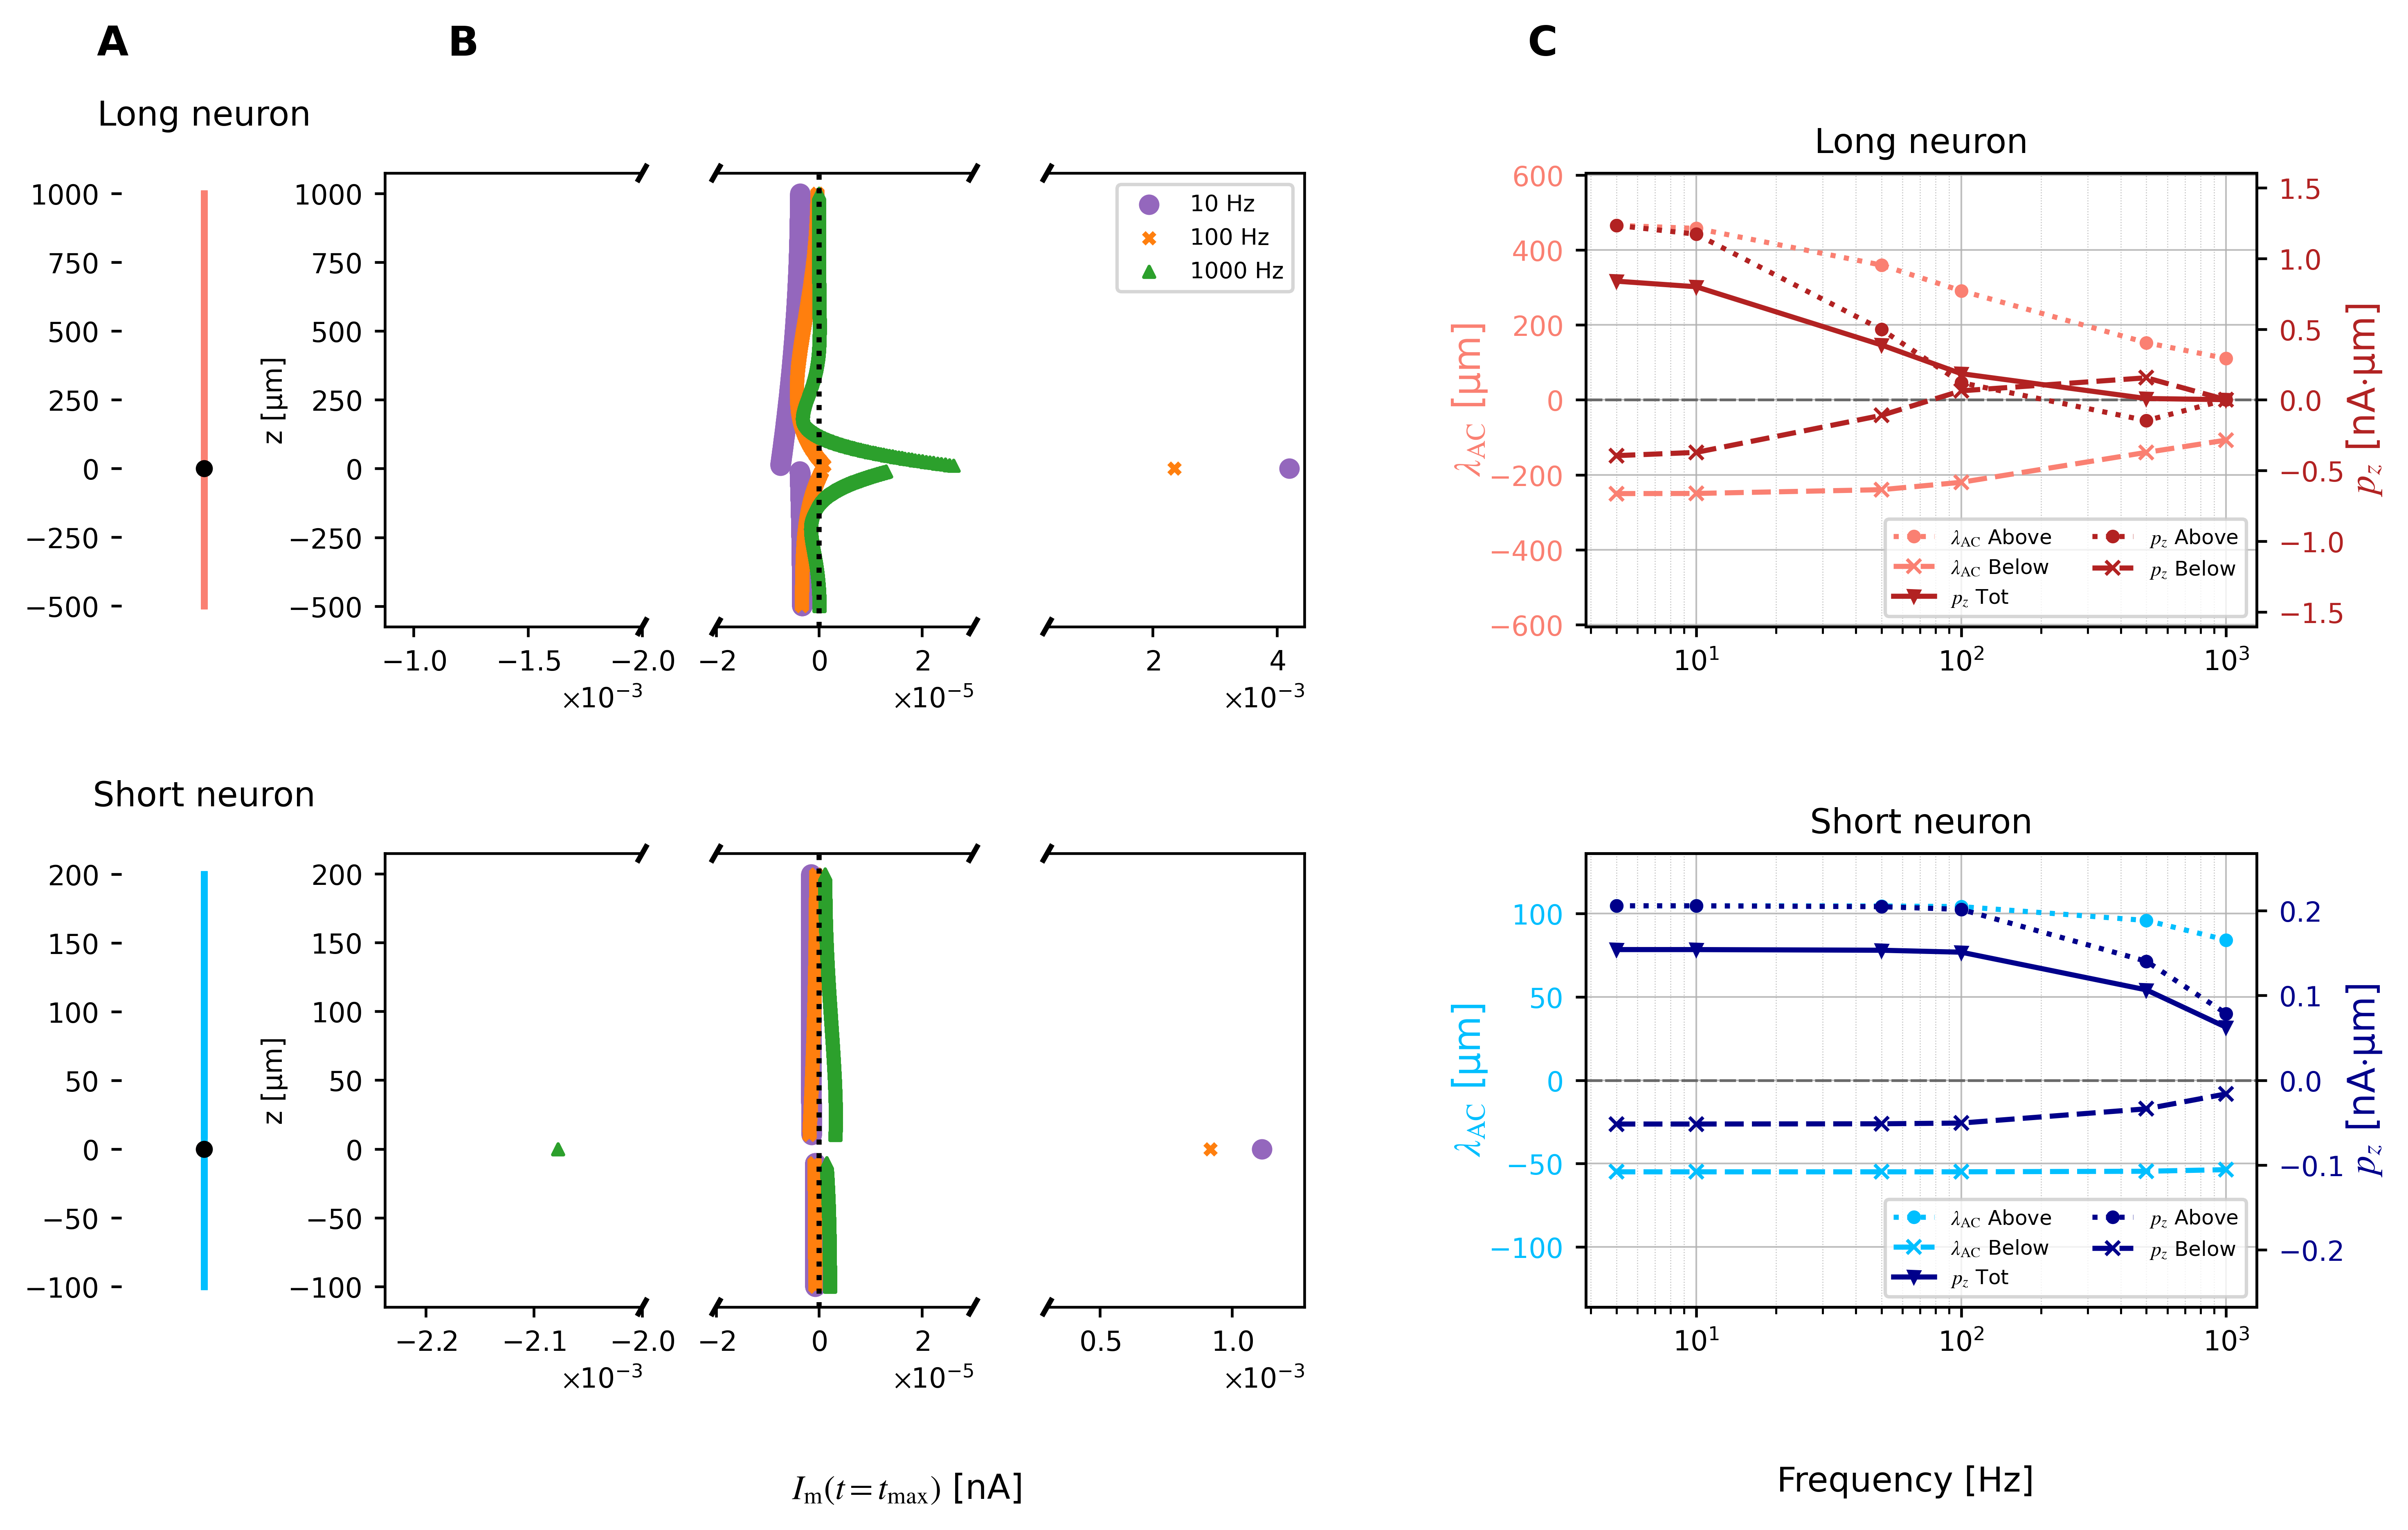

In [8]:
plot_imem_ideal(scatter_imem_data, imem_data, xlim1 = (None, -2e-3), xlim2 = (-2e-5, 3e-5), xlim3 = (3e-4, None))

# Phase differences

Label: BL_-500_UL_1000_SD_20_DD_2
Label: BL_-100_UL_200_SD_20_DD_2


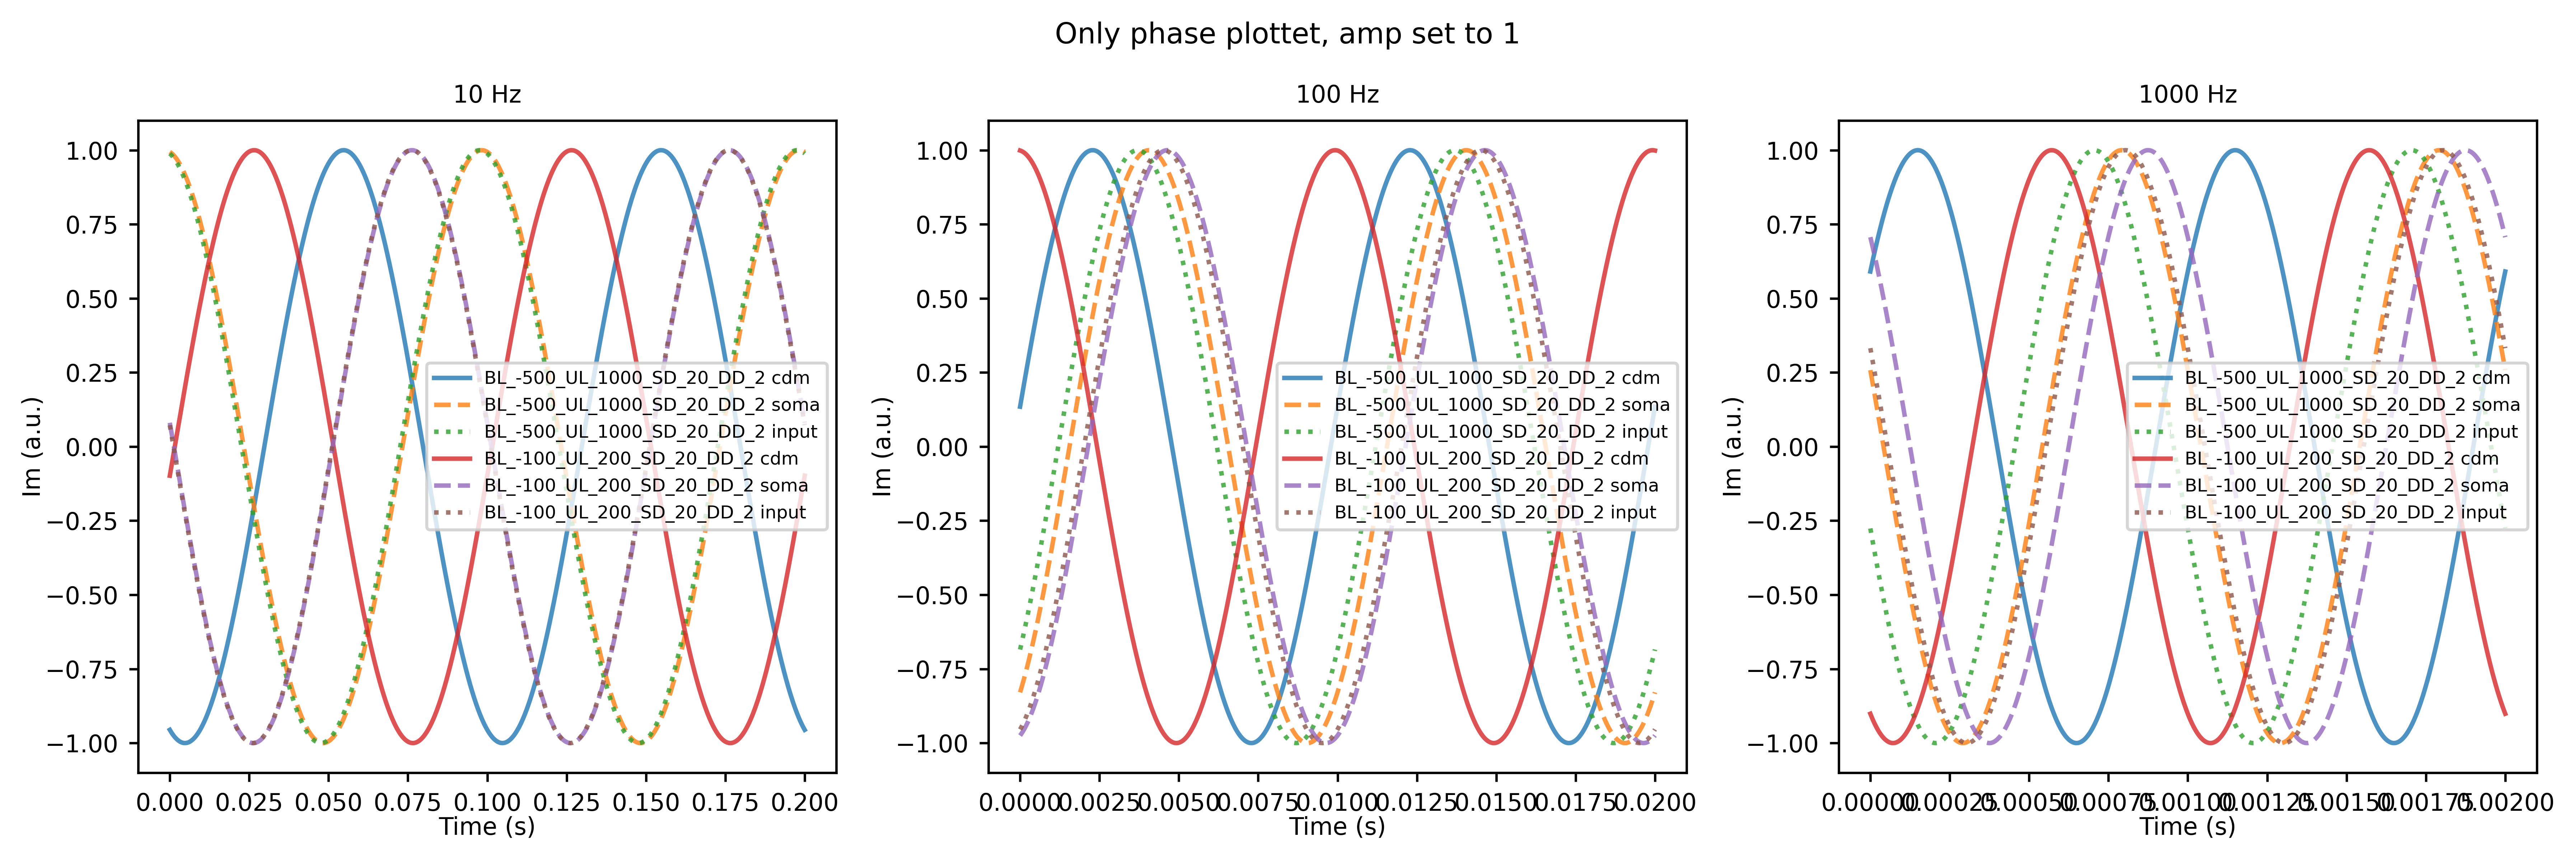

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
ax1, ax2, ax3 = axes

# Frequencies to plot and corresponding time windows
plot_freqs = {
    10: 0.2,      # Hz : seconds
    100: 0.02,
    1000: 0.002
}

# Colors for clarity
colors = ['tab:blue', 'tab:orange', 'tab:green']

for i, label in enumerate(imem_data):
    cell_data = imem_data[label]

    imem_amps = np.array(cell_data['imem_amps'])
    imem_phases = np.array(cell_data['imem_phases'])
    soma_amps = imem_amps[0]
    soma_phases = imem_phases[0]

    input_amps = np.array(cell_data['input_amps'])
    input_phases = np.array(cell_data['input_phases'])

    cdm_amps = np.array(cell_data['cdm'])
    cdm_phases = np.array(cell_data['cdm_phases'])

    print(f"Label: {label}")

    # Loop over frequencies of interest
    for ax, (f, tmax) in zip([ax1, ax2, ax3], plot_freqs.items()):
        # Time vector
        t = np.linspace(0, tmax, 2000)

        # Indices of this frequency in your freqs array
        f_idx = np.where(freqs == f)[0][0]

        # Retrieve amplitude & phase
        cdm_amp = cdm_amps[f_idx]
        cdm_phase = cdm_phases[f_idx]

        soma_amp = soma_amps[f_idx]
        soma_phase = soma_phases[f_idx]

        input_amp = input_amps[f_idx]
        input_phase = input_phases[f_idx]

        # Generate waves
        cdm_wave = 1 * np.sin(2*np.pi*f*t + cdm_phase)
        soma_wave = 1 * np.sin(2*np.pi*f*t + soma_phase)
        input_wave = 1 * np.sin(2*np.pi*f*t + input_phase)

        # Plot
        ax.plot(t, cdm_wave, label=f"{label} cdm", alpha=0.8)
        ax.plot(t, soma_wave, label=f"{label} soma", linestyle='--', alpha=0.8)
        ax.plot(t, input_wave, label=f"{label} input", linestyle=':', alpha=0.8)


# Axis labels and titles
fig.suptitle('Only phase plottet, amp set to 1')
ax1.set_title("10 Hz")
ax2.set_title("100 Hz")
ax3.set_title("1000 Hz")
for ax in [ax1, ax2, ax3]:
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Im (a.u.)")
    ax.legend(fontsize = 6)

plt.tight_layout()
plt.show()


In [10]:
imem_data['BL_-500_UL_1000_SD_20_DD_2']['freqs']

[5, 10, 50, 100, 500, 1000]

In [11]:
scatter_imem_data['BL_-500_UL_1000_SD_20_DD_2']['freqs']

[np.int64(10), np.int64(100), np.int64(1000)]

In [22]:
def plot_imem_ideal(
        cells_data,
        xlim1=(None, -0.002),
        xlim2=(-4e-5, -1e-6),
        xlim3=(-1e-6, None)
    ):

    #imem_amp_dict = load_plot_data_from_files(selected_cells)

    unique_cells = list(cells_data.keys())
    num_cells = len(unique_cells)
    if num_cells == 0:
        print("No cells to plot.")
        return

    # ========================= FIGURE SETUP ==============================
    fig = plt.figure(figsize=(11, 3 * num_cells))
    gs = gridspec.GridSpec(2, 2, figure=fig, width_ratios=[2.5, 1.5], wspace=0.2, hspace=0.4)

    # -- LEFT PANEL: morphology + 3-way broken Im(t)
    # gs_left = gridspec.GridSpecFromSubplotSpec(
    #     num_cells, 4, subplot_spec=main_gs[0, 0],
    #     width_ratios=[1, 1.2, 1.2, 1.2],
    #     wspace=0.3, hspace=0.5
    # )

    # axs_left_panel = {}
    #
    # for i, label in enumerate(unique_cells):
    #     ax_right = fig.add_subplot(gs_left[i, 1])
        #ax_mid  = fig.add_subplot(gs_left[i, 2], sharey=ax_left)
        #ax_right = fig.add_subplot(gs_left[i, 3], sharey=ax_left)

        # axs_left_panel[label] = {
        #     'morph': fig.add_subplot(gs_left[i, 0]),
            #'imem_left': ax_left,
            #'imem_mid': ax_mid,
            # 'imem_right': ax_right,
        # }

    colors_neurons = ['salmon', 'deepskyblue']
    colors_pz = ['firebrick', 'darkblue']
    colors_imem = ['tab:purple', 'tab:orange', 'tab:green']

    for i, label in enumerate(unique_cells):

        # --------------------------- LOAD DATA ----------------------------
        cell_data = cells_data[label]
        x = np.array(cell_data['x'])
        z = np.array(cell_data['z'])
        totnsegs = cell_data['totnsegs']
        freqs = np.array(cell_data['freqs'])
        input_current_phases = cell_data['input_current_phase']
        imem_amps = np.array(cell_data['imem_amps'])
        imem_phases = np.array(cell_data['imem_phases'])
        z_coords = z.mean(axis=-1)

        # Compute t_max for each frequency
        t_max_dict = {}

        # Find the time of maximum pz
        for f in freqs:

            # Find pz above and below at t max
            f_idx = np.argmin(np.abs(freqs - f))
            input_current_phase = input_current_phases[f_idx]
            t_max_inp = (3*np.pi/2 - input_current_phase) / (2*np.pi*f)

            cdm_amp = cdm_amps[f_idx]
            cdm_phase = cdm_phases[f_idx]

            cdm_value = cdm_amp * np.sin(2*np.pi*f*t_max_inp + cdm_phase)
            if f == 10:
                if cdm_value < 0:
                    t_max_cdm_sign = 3
                else:
                    t_max_cdm_sign = 1

            t_max_cdm = (t_max_cdm_sign * np.pi/2 - cdm_phase)/(2*np.pi*f)

            while t_max_cdm < 0:
                t_max_cdm += 1.0 / f

            t_max_dict[f] = t_max_cdm


        # ---- Sub-panels: morphology + two-axis scatter ----
        left_ratio = 1.9
        middle_ratio = 0.6
        right_ratio = 1.2

        inner_gs = gridspec.GridSpecFromSubplotSpec(
            1, 3, subplot_spec=gs[i, 0],
            width_ratios=[left_ratio, middle_ratio, right_ratio], wspace=0.2
        )


        ax_morph = fig.add_subplot(inner_gs[0])
        ax_left = fig.add_subplot(inner_gs[1])
        ax_right = fig.add_subplot(inner_gs[2], sharey=ax_left)


        # --- Morphology ---
        for idx in range(totnsegs):
            ax_morph.plot(x[idx], z[idx], c=cell_vmem_colors[label], lw=1)

        ax_morph.plot(x.mean(axis=-1)[0], z.mean(axis=-1)[0],
                      'o', color='black', markersize=2)

        ax_morph.set_title(f'{cell_names[label]}', fontsize=10)
        ax_morph.set_xticks([])
        ax_morph.set_frame_on(False)
        ax_morph.set_aspect('equal')

        if label == 'L4_BP_bIR215_5':
            ax_morph.set_xlim(np.min(x.mean(axis=-1))-150, np.max(x.mean(axis=-1))+150)
        elif label in ["L5_MC_bAC217_1", "L5_TTPC2_cADpyr232_3"]:
            ax_morph.set_xlim(np.min(x.mean(axis=-1))-50, np.max(x.mean(axis=-1))+50)

        # --- Scatter instantaneous Imem(t_max) ---
        for f_idx, f in enumerate(freqs):

            chosen_t = t_max_dict[f]
            z_imem_map = defaultdict(float)

            for seg_idx in range(totnsegs):
                amp = imem_amps[seg_idx][f_idx]
                phase = imem_phases[seg_idx][f_idx]

                # Instantaneous Imem with direction
                imem_t = amp * np.sin(2*np.pi*f*chosen_t + phase)

                # Sum by z-coordinate
                z_imem_map[z_coords[seg_idx]] += imem_t

            z_vals = list(z_imem_map.keys())
            imem_vals = list(z_imem_map.values())

            # Markers based on freq
            if f == 10:
                marker, size, alpha = 'o', 20, 0.8
            elif f == 100:
                marker, size, alpha = 'x', 10, 0.8
            else:
                marker, size, alpha = '^', 6, 0.5

            ax_left.scatter(imem_vals, z_vals,
                            label=f'{f} Hz', alpha=alpha, marker=marker,
                            color=freq_colors[f_idx], s=size)

            ax_right.scatter(imem_vals, z_vals,
                             label=f'{f} Hz', alpha=alpha, marker=marker,
                             color=freq_colors[f_idx], s=size)

        # --- Axis settings ---
        ax_left.axvline(0, color='black', linestyle=':')
        ax_right.axvline(0, color='black', linestyle=':')

        ax_left.set_xlim(xlim1)

        # Determine xmax from instantaneous Imem
        all_vals = np.array([
            imem_amps[seg_idx][f_idx] *
            np.sin(2*np.pi*freqs[f_idx]*t_max_dict[freqs[f_idx]] +
                   imem_phases[seg_idx][f_idx])
            for seg_idx in range(totnsegs)
            for f_idx in range(len(freqs))
        ])

        if xlim2[1] is None:
            xmax = np.max(np.abs(all_vals))
            ax_right.set_xlim((xlim2[0], xmax + 0.0001))
        else:
            ax_right.set_xlim(xlim2)

        # Hide ticks/spines
        ax_right.yaxis.set_visible(False)
        ax_right.spines['left'].set_visible(False)
        ax_left.spines['right'].set_visible(False)

        # Add diagonal breaks
        # size of diagonal in axes coordinates (vertical portion)
        d = 0.015

        # left -> middle break
        kwargs = dict(transform=ax_left.transAxes, color='k', clip_on=False)
        ax_left.plot([1-d*middle_ratio/left_ratio, 1+d*middle_ratio/left_ratio], [-d, +d], **kwargs)
        ax_left.plot([1-d*middle_ratio/left_ratio, 1+d*middle_ratio/left_ratio], [1-d, 1+d], **kwargs)

        # middle -> right break
        kwargs.update(transform=ax_right.transAxes)
        ax_right.plot([-d*middle_ratio/right_ratio, +d*middle_ratio/right_ratio], [-d, +d], **kwargs)
        ax_right.plot([-d*middle_ratio/right_ratio, +d*middle_ratio/right_ratio], [1-d, 1+d], **kwargs)

        # x-ticks on scatterplot
        fmt_left = ScalarFormatter(useMathText=True)
        fmt_left.set_powerlimits((-2, 2))
        ax_left.ticklabel_format(style='sci', axis='x', scilimits=(-2, 2))
        ax_left.xaxis.set_major_formatter(fmt_left)
        ax_left.tick_params(axis='x', labelsize=7)

        fmt_right = ScalarFormatter(useMathText=True)
        fmt_right.set_powerlimits((-2, 2))
        ax_right.ticklabel_format(style='sci', axis='x', scilimits=(-2, 2))
        ax_right.xaxis.set_major_formatter(fmt_right)
        ax_right.tick_params(axis='x', labelsize=7)

        if i == 0:
            ax_right.legend(loc='lower right', fontsize=8)
        if i == 2:
            ax_left.yaxis.set_major_locator(MultipleLocator(250))

        # y-label
        ax_left.set_ylabel('z [µm]', fontsize=10)
    # Shared x-label
    fig.text(0.47, 0.07, 'Sum of $I_m(t = t_{max})$ [nA]', ha='center', fontsize=10)

    # =======================================================
    # RIGHT COLUMN: λ_AC and p_z frequency plots (unchanged)
    # =======================================================

    for i, cell_name in enumerate(unique_cells):

        ax_right_cell = fig.add_subplot(gs[i, 1])

        cell_info = avg_imem_data_dict[cell_name]
        frequency = cell_info['frequency']
        avg_pos_above = cell_info['avg_return_pos_above_soma']
        avg_pos_below = cell_info['avg_return_pos_below_soma']
        cdm_amps = cell_info['cdm']
        cdm_phases = cell_info['cdm_phase']
        cdm_pos_amps = cell_info['cdm_pos']
        cdm_neg_amps = cell_info['cdm_neg']
        cdm_pos_phases = cell_info['cdm_phase_pos']
        cdm_neg_phases = cell_info['cdm_phase_neg']
        input_current_phases = cell_info['input_current_phase']

        ax_right_cell.axhline(0, color = 'dimgray', linestyle = (0, (6,1)), linewidth=0.8)

        # ======== First axis: λ_AC ========
        ax_right_cell.semilogx(
            frequency[:-1], avg_pos_above[:-1],
            label='$\lambda_{AC}$ Above',
            color=cell_vmem_colors[cell_name], linestyle=':'
        )
        ax_right_cell.semilogx(
            frequency[:-1], avg_pos_below[:-1],
            label='$\lambda_{AC}$ Below',
            color=cell_vmem_colors[cell_name], linestyle='--'
        )

        ax_right_cell.set_title(f'{short_cell_names[cell_name]}', fontsize=10)
        ax_right_cell.set_xlim(1, 2000)
        lam_ylim = 1.2*max(np.max(avg_pos_above), np.max(np.abs(avg_pos_below)))
        ax_right_cell.set_ylim(-lam_ylim, lam_ylim)
        ax_right_cell.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.8)
        ax_right_cell.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.8)
        ax_right_cell.set_ylabel('$\lambda_{AC}$ [µm]', fontsize=11, color=cell_vmem_colors[cell_name])
        ax_right_cell.tick_params(axis='y', labelcolor=cell_vmem_colors[cell_name])

        # ======== Second axis: CDM p_z ========
        ax2 = ax_right_cell.twinx()

        cdm_max_values = []
        cdm_values_pos = []
        cdm_values_neg = []
        for f_idx, f in enumerate(frequency):
            input_phase = input_current_phases[f_idx]
            t_max_inp = (3*np.pi/2 - input_phase)/(2*np.pi*f)

            cdm_amp = cdm_amps[f_idx]
            cdm_phase = cdm_phases[f_idx]
            cdm_value = cdm_amp * np.sin(2*np.pi*f*t_max_inp + cdm_phase)

            if f_idx == 0:
                if cdm_value < 0:
                    t_max_cdm_sign = 3
                else:
                    t_max_cdm_sign = 1

            t_max_cdm = (t_max_cdm_sign * np.pi/2 - cdm_phase)/(2*np.pi*f)

            cdm_max_value = cdm_amp * np.sin(2*np.pi*f*t_max_cdm + cdm_phase)
            cdm_max_values.append(cdm_max_value)

            cdm_pos_amp = cdm_pos_amps[f_idx]
            cdm_pos_phase = cdm_pos_phases[f_idx]
            cdm_value_pos = cdm_pos_amp * np.sin(2*np.pi*f*t_max_cdm + cdm_pos_phase)
            cdm_values_pos.append(cdm_value_pos)

            cdm_neg_amp = cdm_neg_amps[f_idx]
            cdm_neg_phase = cdm_neg_phases[f_idx]
            cdm_value_neg = cdm_neg_amp * np.sin(2*np.pi*f*t_max_cdm + cdm_neg_phase)
            cdm_values_neg.append(cdm_value_neg)

        ax2.semilogx(
            frequency[:-1], cdm_max_values[:-1],
            label='$p_z$ Tot',
            color=cell_cdm_colors[cell_name], linestyle='-'
        )

        ax2.semilogx(
            frequency[:-1], cdm_values_pos[:-1],
            label='$p_z$ Above',
            color=cell_cdm_up_down_colors[cell_name], linestyle=':'
        )
        ax2.semilogx(
            frequency[:-1], cdm_values_neg[:-1],
            label='$p_z$ Below',
            color=cell_cdm_up_down_colors[cell_name], linestyle='--'
        )

        ax2.set_xlim(1, 2000)
        cdm_ylim = 1.2*max(np.max(cdm_values_pos), np.max(np.abs(cdm_values_neg)))
        ax2.set_ylim(-cdm_ylim, cdm_ylim)
        ax2.set_ylabel('$p_z$ [nA·µm]', fontsize=11, color = cell_cdm_colors[cell_name])
        ax2.tick_params(axis='y', labelcolor=cell_cdm_colors[cell_name])

        # ======== Combined legend ========
        # Get handles/labels from both axes
        h1, l1 = ax_right_cell.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()

        if cell_name == 'L4_SS_cADpyr230_1':
            loc = 'center left'
        elif cell_name == 'L5_NGC_bNAC219_5':
            loc = 'center'
        elif cell_name == 'L5_TTPC2_cADpyr232_3':
            loc = 'lower right'
        else: loc = 'best'
        ax2.legend(h1 + h2, l1 + l2, fontsize=7, loc=loc,
                frameon=True, fancybox=True, framealpha=0.9, ncol =2)


    fig.text(0.78, 0.07, 'Frequency (Hz)', ha='center', fontsize=10)

    fig.text(0.14, 0.91, 'A', fontsize=12, fontweight='bold')
    fig.text(0.33, 0.91, 'B', fontsize=12, fontweight='bold')
    fig.text(0.62, 0.91, 'C', fontsize=12, fontweight='bold')

    plt.savefig('fig6___.pdf',
                bbox_inches='tight')
    plt.show()
    fig.savefig("fig6_iiii.pdf", bbox_inches='tight')
    plt.show()

<>:262: SyntaxWarning: invalid escape sequence '\c'
<>:262: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_215520/2997365852.py:262: SyntaxWarning: invalid escape sequence '\c'
  ax2.set_ylabel('$p_z$ [nA$\cdot$µm]', fontsize=11, color=colpz)


(1001, 3) (1001,)
(1001,) (1001,)
(1001,) (1001,)
(1001,) (1001,)
(1001, 3) (1001,)
(1001,) (1001,)
(1001,) (1001,)
(1001,) (1001,)


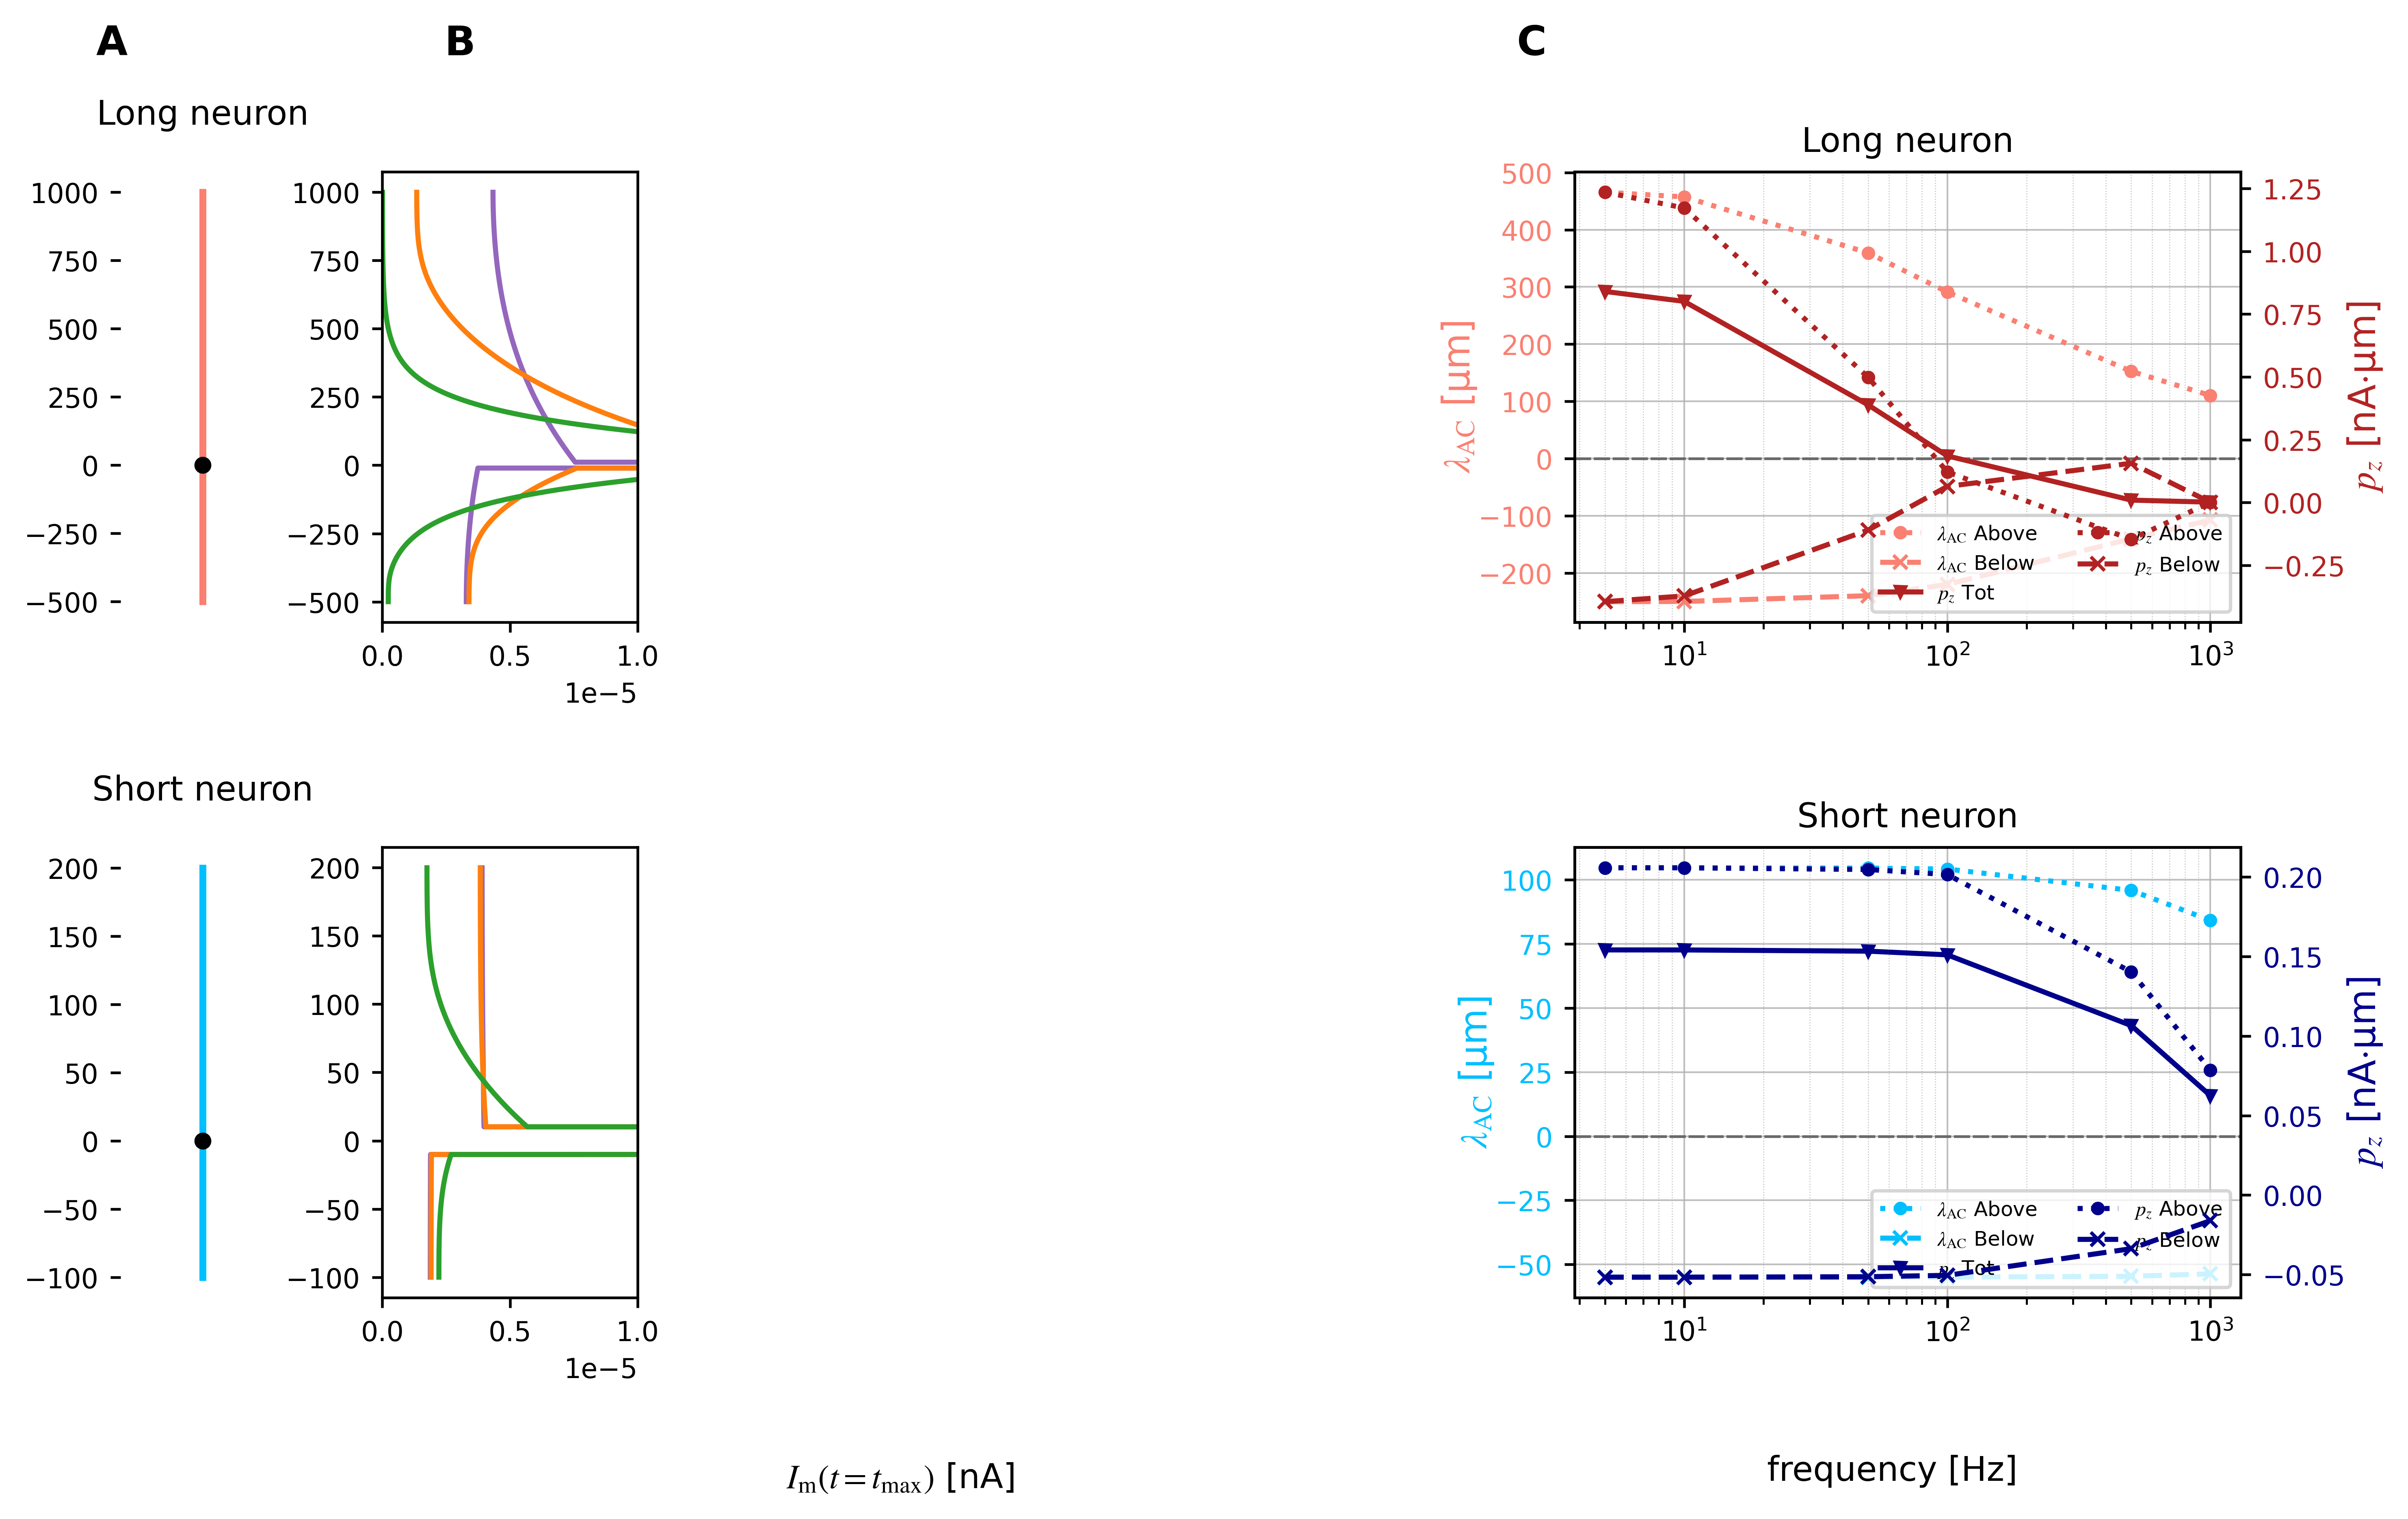

In [23]:
plot_imem_ideal(scatter_imem_data, xlim1 = (None, -2e-3), xlim2 = (-2e-5, 3e-5), xlim3 = (3e-4, None))

In [55]:
scatter_imem_data.keys()

dict_keys(['BL_-500_UL_1000_SD_20_DD_2', 'BL_-100_UL_200_SD_20_DD_2'])

In [27]:
imem_data['BL_-500_UL_1000_SD_20_DD_2'].keys()

dict_keys(['freqs', 'x', 'z', 'totnsegs', 'tvec', 'imem_amps', 'imem_phases', 'positive_avg_imem_pos', 'negative_avg_imem_pos', 'input_amps', 'input_phases', 'cdm', 'cdm_phases', 'cdm_pos', 'cdm_pos_phases', 'cdm_neg', 'cdm_neg_phases'])

In [84]:
color_neurons = {
    'BL_-500_UL_1000_SD_20_DD_2': 'salmon',
    'BL_-100_UL_200_SD_20_DD_2': 'deepskyblue'
}
cell_names = {
    'BL_-500_UL_1000_SD_20_DD_2': 'long neuron',
    'BL_-100_UL_200_SD_20_DD_2': 'short neuron'
}

cell_cdm_colors = {
    'BL_-500_UL_1000_SD_20_DD_2': 'firebrick'   ,
    'BL_-100_UL_200_SD_20_DD_2': 'darkblue'
}
cell_cdm_up_down_colors = {
    'BL_-500_UL_1000_SD_20_DD_2': 'firebrick'   ,
    'BL_-100_UL_200_SD_20_DD_2': 'darkblue'
}

def plot_imem_figure_ideal_mod(imem_amp_dict, xlim1=(0, 0.0003), xlim2=(0.0018, None)):

    unique_cells = [cell for cell in imem_amp_dict]

    num_cells = len(unique_cells)

    # --- Figure layout ---
    fig = plt.figure(figsize=(10, 15))
    gs = gridspec.GridSpec(5, 2, width_ratios=[2.5, 1.5],
                           height_ratios=[1, 1, 1, 1, 1],
                           wspace=0.2, hspace=0.4)

    freq_colors = ['tab:purple', 'tab:orange', 'tab:green']

    # ================================================
    # LEFT COLUMN: scatter of instantaneous Imem(t_max)
    # ================================================
    for i, label in enumerate(unique_cells):

        cell_data = imem_amp_dict[label]
        x = np.array(cell_data['x'])
        z = np.array(cell_data['z'])
        totnsegs = cell_data['totnsegs']
        freqs = np.array(cell_data['freqs'])

        imem_amps = np.array(cell_data['imem_amps'])      # shape: (seg, freq)
        imem_phases = np.array(cell_data['imem_phases'])   # shape: (seg, freq)

        amp_data = cell_data
        amp_freqs = freqs#np.array(amp_data['frequency'])
        input_current_phases = amp_data['input_phases']
        cdm_amps = np.array(amp_data['cdm'])
        cdm_phases = np.array(amp_data['cdm_phases'])
        z_coords = z.mean(axis=-1)

        # Compute t_max for each frequency
        t_max_dict = {}

        # Find direction of pz at 1 Hz
        input_current_phase_0 = input_current_phases[0]
        t_max_inp_0 = (3*np.pi/2 - input_current_phase_0) / (2*np.pi* amp_freqs[0])
        cdm_amp_0 = cdm_amps[0]
        cdm_phase_0 = cdm_phases[0]
        cdm_value_0 = cdm_amp_0 * np.sin(2*np.pi* amp_freqs[0] *t_max_inp_0 + cdm_phase_0)
        if cdm_value_0 < 0:
            t_max_cdm_sign = 3
        else:
            t_max_cdm_sign = 1
        # Find the time of maximum pz
        for f in freqs:
            # Find pz above and below at t max
            f_idx = np.argmin(np.abs(amp_freqs - f))
            cdm_amp = cdm_amps[f_idx]
            cdm_phase = cdm_phases[f_idx]

            t_max_cdm = (t_max_cdm_sign * np.pi/2 - cdm_phase)/(2*np.pi*f)

            while t_max_cdm < 0:
                t_max_cdm += 1.0 / f

            t_max_dict[f] = t_max_cdm

        # ---- Sub-panels: morphology + two-axis scatter ----
        left_ratio = 1.9
        middle_ratio = 0.6
        right_ratio = 1.2

        inner_gs = gridspec.GridSpecFromSubplotSpec(
            1, 3, subplot_spec=gs[i, 0],
            width_ratios=[left_ratio, middle_ratio, right_ratio], wspace=0.2
        )

        ax_morph = fig.add_subplot(inner_gs[0])
        ax_left = fig.add_subplot(inner_gs[1])
        ax_right = fig.add_subplot(inner_gs[2], sharey=ax_left)

        # --- Morphology ---
        for idx in range(totnsegs):
            ax_morph.plot(x[idx], z[idx], c=color_neurons[label], lw=1)

        ax_morph.plot(x.mean(axis=-1)[0], z.mean(axis=-1)[0],
                      'o', color='black', markersize=2)

        ax_morph.set_title(f'{cell_names[label]}', fontsize=10)
        ax_morph.set_xticks([])
        ax_morph.set_yticks([])
        x_lab = np.min(x) - 50
        if "L5_NGC" in label:
            ax_morph.plot([x_lab, x_lab], [np.min(z), np.min(z) + 200], clip_on=False, c='k', lw=1)
            ax_morph.text(x_lab - 25, 0, "200\nµm", va='center', ha="right")

        else:
            ax_morph.plot([x_lab, x_lab], [0, -200], clip_on=False, c='k', lw=1)
            ax_morph.text(x_lab - 25, -100, "200\nµm", va='center', ha="right")
        ax_morph.set_frame_on(False)
        ax_morph.set_aspect('equal')

        if label == 'L4_BP_bIR215_5':
            ax_morph.set_xlim(np.min(x.mean(axis=-1))-150, np.max(x.mean(axis=-1))+150)
        elif label in ["L5_MC_bAC217_1", "L5_TTPC2_cADpyr232_3"]:
            ax_morph.set_xlim(np.min(x.mean(axis=-1))-50, np.max(x.mean(axis=-1))+50)

        # --- Scatter instantaneous Imem(t_max) ---
        for f_idx, f in enumerate(plot_freqs):

            chosen_t = t_max_dict[f]
            z_imem_map = defaultdict(float)

            # -------- compute full-tree values (unchanged) -------------
            for seg_idx in range(totnsegs):
                amp = imem_amps[seg_idx][f_idx]
                phase = imem_phases[seg_idx][f_idx]

                imem_t = amp * np.sin(2*np.pi*f*chosen_t + phase)
                z_imem_map[z_coords[seg_idx]] += imem_t

            z_vals = list(z_imem_map.keys())
            imem_vals = list(z_imem_map.values())

            # Marker styling unchanged
            if f == 10:
                marker, size, alpha = 'o', 20, 0.8
            elif f == 100:
                marker, size, alpha = 'x', 10, 0.8
            else:
                marker, size, alpha = '^', 6, 0.5

            # ============================================================
            # SOMA-ONLY PLOT FOR ax_left  (THIS IS THE ONLY MODIFICATION)
            # ============================================================
            soma_amp = imem_amps[0][f_idx]
            soma_phase = imem_phases[0][f_idx]
            soma_imem_t = soma_amp * np.sin(2*np.pi*f*chosen_t + soma_phase)
            soma_z = z_coords[0]

            ax_left.scatter(
                soma_imem_t, soma_z,
                label=f'{f} Hz', alpha=alpha, marker=marker,
                color=freq_colors[f_idx], s=size
            )

            # ---------------- full-branch scatter for ax_right ------------
            ax_right.scatter(
                imem_vals, z_vals,
                label=f'{f} Hz', alpha=alpha, marker=marker,
                color=freq_colors[f_idx], s=size
            )

        # --- Axis settings ---
        ax_left.axvline(0, color='black', linestyle=':')
        ax_right.axvline(0, color='black', linestyle=':')

        ax_left.set_xlim(xlim1)

        # Determine xmax from instantaneous Imem
        # all_vals = np.array([
        #     imem_amps[seg_idx][f_idx] *
        #     np.sin(2*np.pi*freqs[f_idx]*t_max_dict[freqs[f_idx]] +
        #            imem_phases[seg_idx][f_idx])
        #     for seg_idx in range(totnsegs)
        #     for f_idx in range(len(freqs))
        # ])

        # x-lim for right scatter
        if label == 'L4_SS_cADpyr230_1':
            right_lim =(-1.3e-4, 0.8e-4)
        else:
            right_lim = xlim2
        ax_right.set_xlim(right_lim)

        # Hide ticks/spines
        ax_right.yaxis.set_visible(False)
        ax_right.spines['left'].set_visible(False)
        ax_left.spines['right'].set_visible(False)

        # Add diagonal breaks
        d = 0.015
        kwargs = dict(transform=ax_left.transAxes, color='k', clip_on=False)
        ax_left.plot([1-d*middle_ratio/left_ratio, 1+d*middle_ratio/left_ratio], [-d, +d], **kwargs)
        ax_left.plot([1-d*middle_ratio/left_ratio, 1+d*middle_ratio/left_ratio], [1-d, 1+d], **kwargs)

        kwargs.update(transform=ax_right.transAxes)
        ax_right.plot([-d*middle_ratio/right_ratio, +d*middle_ratio/right_ratio], [-d, +d], **kwargs)
        ax_right.plot([-d*middle_ratio/right_ratio, +d*middle_ratio/right_ratio], [1-d, 1+d], **kwargs)

        # x-ticks on scatterplot
        fmt_left = ScalarFormatter(useMathText=True)
        fmt_left.set_powerlimits((-2, 2))
        ax_left.ticklabel_format(style='sci', axis='x', scilimits=(-2, 2))
        ax_left.xaxis.set_major_formatter(fmt_left)
        ax_left.tick_params(axis='x', labelsize=7)

        fmt_right = ScalarFormatter(useMathText=True)
        fmt_right.set_powerlimits((-2, 2))
        ax_right.ticklabel_format(style='sci', axis='x', scilimits=(-2, 2))
        ax_right.xaxis.set_major_formatter(fmt_right)
        ax_right.tick_params(axis='x', labelsize=7)

        if i == 1:
            ax_right.legend(loc='upper right', fontsize=8)
        if i == 2:
            ax_left.yaxis.set_major_locator(MultipleLocator(250))

        ax_left.set_ylabel('$z$ [µm]', fontsize=10)

    fig.text(0.47, 0.07, r'sum of $I_{\rm m}(t = t_{\rm max})$ [nA]', ha='center', fontsize=10)

    # =======================================================
    # RIGHT COLUMN: λ_AC and p_z frequency plots (unchanged)
    # =======================================================

    for i, cell_name in enumerate(unique_cells):
        cell_info = imem_amp_dict[label]
        ax_right_cell = fig.add_subplot(gs[i, 1])

        frequency = np.array(cell_info['freqs'])
        avg_pos_above = cell_info['positive_avg_imem_pos']
        avg_pos_below = cell_info['negative_avg_imem_pos']
        cdm_amps = cell_info['cdm']
        cdm_phases = cell_info['cdm_phases']
        cdm_pos_amps = cell_info['cdm_pos']
        cdm_neg_amps = cell_info['cdm_neg']
        cdm_pos_phases = cell_info['cdm_pos_phases']
        cdm_neg_phases = cell_info['cdm_neg_phases']
        input_current_phases = cell_info['input_phases']

        print(cdm_pos_phases)

        ax_right_cell.axhline(0, color = 'dimgray', linestyle = (0, (6,1)), linewidth=0.8)

        # ======== First axis: λ_AC ========
        ax_right_cell.semilogx(
            frequency[:-1], avg_pos_above[:-1],
            label=r'$\lambda_{\rm AC}$ above',
            color=color_neurons[cell_name], linestyle=':'
        )
        ax_right_cell.semilogx(
            frequency[:-1], avg_pos_below[:-1],
            label=r'$\lambda_{\rm AC}$ below',
            color=color_neurons[cell_name], linestyle='--'
        )

        #ax_right_cell.set_title(f'{short_cell_names[cell_name]}', fontsize=10)
        ax_right_cell.set_xlim(1, 2000)
        lam_ylim = 1.2*max(np.max(avg_pos_above), np.max(np.abs(avg_pos_below)))
        ax_right_cell.set_ylim(-lam_ylim, lam_ylim)
        #ax_right_cell.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.8)
        #ax_right_cell.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.8)
        ax_right_cell.set_ylabel(r'$\lambda_{\rm AC}$ [µm]', fontsize=11, color=color_neurons[cell_name])
        ax_right_cell.tick_params(axis='y', labelcolor=color_neurons[cell_name])

        # ======== Second axis: CDM p_z ========
        ax2 = ax_right_cell.twinx()
        ax_right_cell.grid(False)
        ax2.grid(False)
        cdm_max_values = []
        cdm_values_pos = []
        cdm_values_neg = []
        for f_idx, f in enumerate(frequency):
            input_phase = input_current_phases[f_idx]
            t_max_inp = (3*np.pi/2 - input_phase)/(2*np.pi*f)

            cdm_amp = cdm_amps[f_idx]
            cdm_phase = cdm_phases[f_idx]
            cdm_value = cdm_amp * np.sin(2*np.pi*f*t_max_inp + cdm_phase)

            if f_idx == 0:
                if cdm_value < 0:
                    t_max_cdm_sign = 3
                else:
                    t_max_cdm_sign = 1

            t_max_cdm = (t_max_cdm_sign * np.pi/2 - cdm_phase)/(2*np.pi*f)
            #t_max_cdm = (np.pi/2 - cdm_phase)/(2*np.pi*f)

            cdm_max_value = cdm_amp * np.sin(2*np.pi*f*t_max_cdm + cdm_phase)
            cdm_max_values.append(cdm_max_value)

            cdm_pos_amp = cdm_pos_amps[f_idx]
            cdm_pos_phase = cdm_pos_phases[f_idx]
            cdm_value_pos = cdm_pos_amp * np.sin(2*np.pi*f*t_max_cdm + cdm_pos_phase)
            cdm_values_pos.append(cdm_value_pos)

            cdm_neg_amp = cdm_neg_amps[f_idx]
            cdm_neg_phase = cdm_neg_phases[f_idx]
            cdm_value_neg = cdm_neg_amp * np.sin(2*np.pi*f*t_max_cdm + cdm_neg_phase)
            cdm_values_neg.append(cdm_value_neg)

            #print(f"Check: {cdm_max_value - cdm_value_pos + cdm_value_neg}")
        freq_idx_1Hz = np.argmin(np.abs(frequency - 1))
        freq_idx_1000Hz = np.argmin(np.abs(frequency - 1000))
        print(cell_name, np.array(frequency)[freq_idx_1Hz], np.array(cdm_max_values)[freq_idx_1Hz])
        print(cell_name, np.array(frequency)[freq_idx_1000Hz], np.array(cdm_max_values)[freq_idx_1000Hz])



        ax2.semilogx(
            frequency[:-1], cdm_max_values[:-1],
            label=r'$p_z$ total',
            color=cell_cdm_colors[cell_name], linestyle='-'
        )

        ax2.semilogx(
            frequency[:-1], cdm_values_pos[:-1],
            label=r'$p_z$ above',
            color=cell_cdm_up_down_colors[cell_name], linestyle=':'
        )
        ax2.semilogx(
            frequency[:-1], cdm_values_neg[:-1],
            label=r'$p_z$ below',
            color=cell_cdm_up_down_colors[cell_name], linestyle='--'
        )

        ax2.set_xlim(1, 2000)
        cdm_ylim = 1.2*max(np.max(cdm_values_pos), np.max(np.abs(cdm_values_neg)))
        ax2.set_ylim(-cdm_ylim, cdm_ylim)
        ax2.set_ylabel(r'$p_z$ [nA·µm]', fontsize=11, color = cell_cdm_colors[cell_name])

        ax2.tick_params(axis='y', labelcolor=cell_cdm_colors[cell_name])

        # ======== Combined legend ========
        h1, l1 = ax_right_cell.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()

        if cell_name == 'L4_SS_cADpyr230_1':
            loc = 'center left'
        elif cell_name == 'L5_NGC_bNAC219_5':
            loc = 'center'
        elif cell_name == 'L5_TTPC2_cADpyr232_3':
            loc = 'lower right'
        else:
            loc = 'best'

        ax2.legend(h1 + h2, l1 + l2, fontsize=7, loc=loc,
                frameon=True, fancybox=True, framealpha=0.9, ncol =2)

    fig.text(0.78, 0.07, 'frequency [Hz]', ha='center', fontsize=10)

    fig.text(0.14, 0.91, 'A', fontsize=12, fontweight='bold')
    fig.text(0.33, 0.91, 'B', fontsize=12, fontweight='bold')
    fig.text(0.62, 0.91, 'C', fontsize=12, fontweight='bold')

    plt.savefig('fig6_iiii.pdf',
                bbox_inches='tight')
    plt.show()


[np.float64(1.8869816642523818), np.float64(-0.09111793344887104), np.float64(-1.1289898720137486), np.float64(1.6905851818446032), np.float64(2.665872542948272), np.float64(-1.3724316371752143)]
BL_-500_UL_1000_SD_20_DD_2 5 0.15418680322567876
BL_-500_UL_1000_SD_20_DD_2 1000 0.06252040019645895
[np.float64(1.8869816642523818), np.float64(-0.09111793344887104), np.float64(-1.1289898720137486), np.float64(1.6905851818446032), np.float64(2.665872542948272), np.float64(-1.3724316371752143)]
BL_-100_UL_200_SD_20_DD_2 5 0.15418680322567876
BL_-100_UL_200_SD_20_DD_2 1000 0.06252040019645895


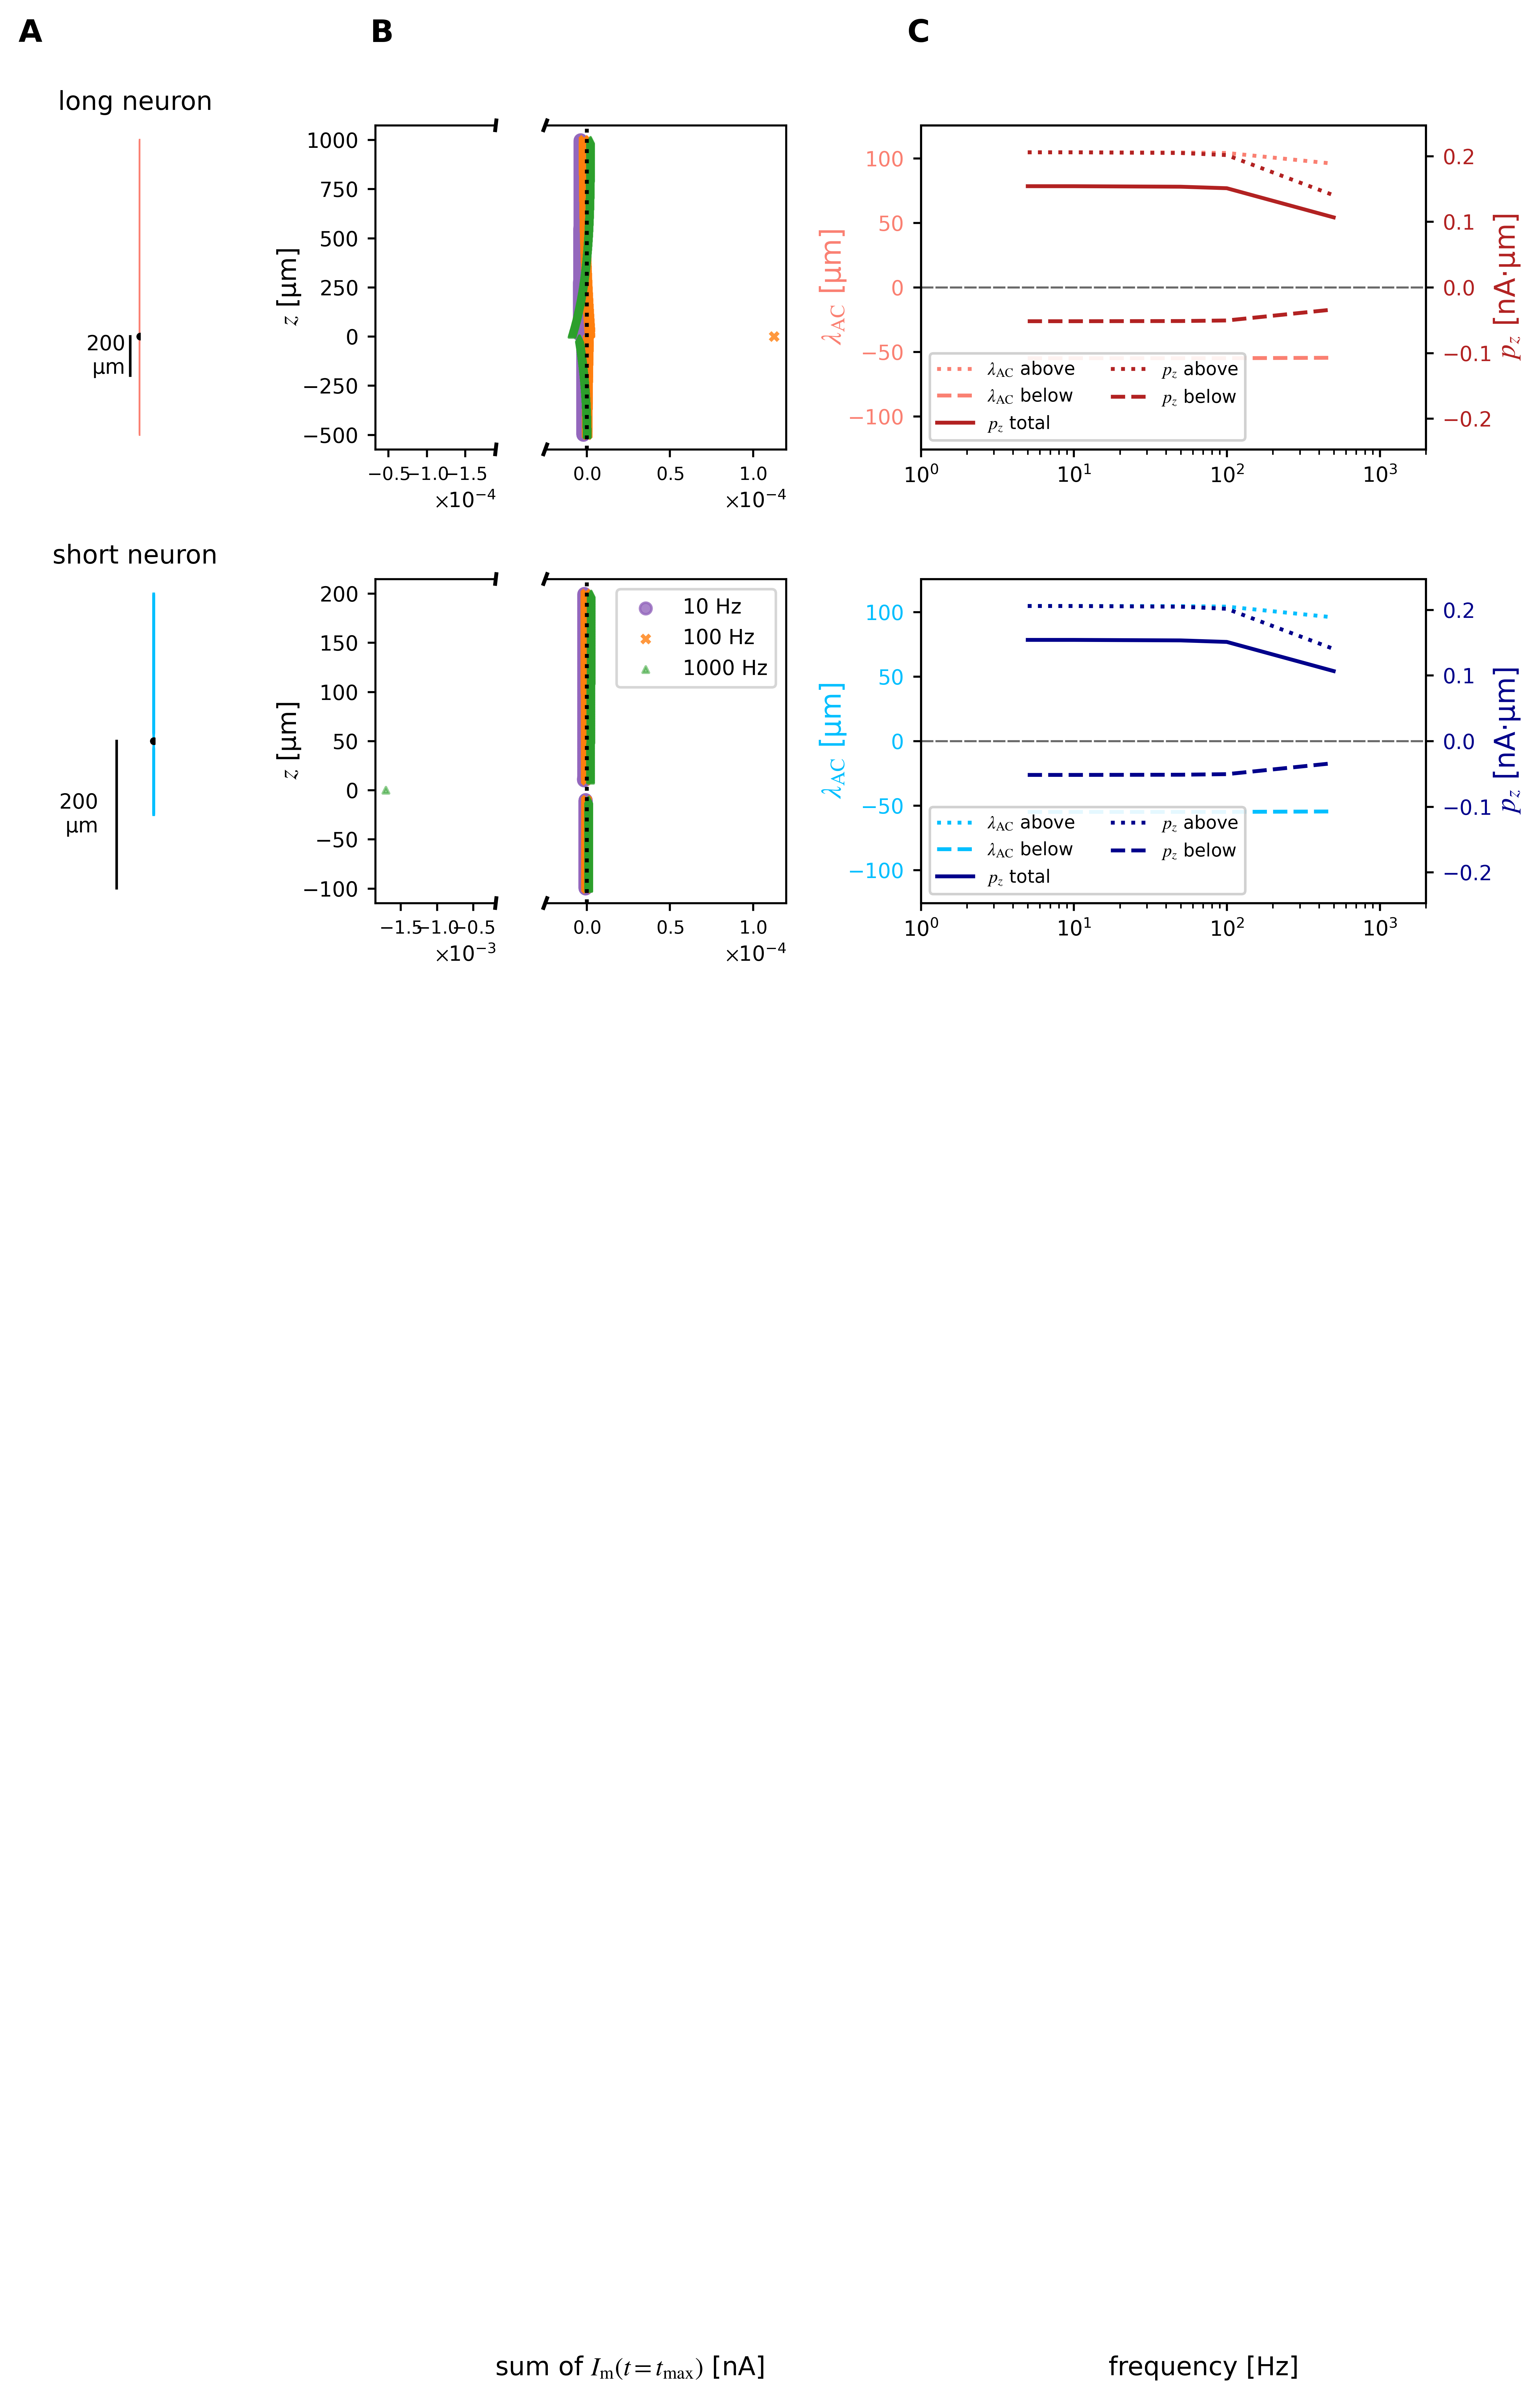

In [85]:
plot_imem_figure_ideal_mod(imem_data, xlim1=(None, -1.9e-4), xlim2=(-2.5e-5, 1.2e-4))


In [7]:
print(imem_data['BL_-500_UL_1000_SD_20_DD_2'].keys())
print(imem_data.keys())


dict_keys(['freqs', 'x', 'z', 'totnsegs', 'tvec', 'imem_amps', 'imem_phases', 'positive_avg_imem_pos', 'negative_avg_imem_pos', 'input_amps', 'input_phases', 'cdm', 'cdm_phases', 'cdm_pos', 'cdm_pos_phases', 'cdm_neg', 'cdm_neg_phases'])
dict_keys(['BL_-500_UL_1000_SD_20_DD_2', 'BL_-100_UL_200_SD_20_DD_2'])


In [8]:
np.array(imem_data['BL_-500_UL_1000_SD_20_DD_2']['imem_amps'])

array([[4.28375270e-03, 4.26124853e-03, 4.00605421e-03, 3.74302462e-03,
        2.73390336e-03, 2.26295654e-03],
       [7.15081662e-06, 7.55304836e-06, 1.16299095e-05, 1.53788154e-05,
        2.61236711e-05, 3.04524623e-05],
       [7.13875540e-06, 7.53670265e-06, 1.15757351e-05, 1.52830547e-05,
        2.57648557e-05, 2.98573180e-05],
       ...,
       [3.14520131e-06, 3.28744643e-06, 3.91205589e-06, 3.39310341e-06,
        8.48696831e-07, 2.30315297e-07],
       [3.14519527e-06, 3.28744011e-06, 3.91204820e-06, 3.39309629e-06,
        8.48691410e-07, 2.30310742e-07],
       [3.14519225e-06, 3.28743695e-06, 3.91204435e-06, 3.39309273e-06,
        8.48688706e-07, 2.30308472e-07]], shape=(1001, 6))

[   1    5   10   50  100  500 1000]
BL_-500_UL_1000_SD_20_DD_2 pz at 1 Hz: 0.8527476142045303
BL_-500_UL_1000_SD_20_DD_2 pz at 5 Hz: 0.8392065739616368
BL_-500_UL_1000_SD_20_DD_2 pz at 10 Hz: 0.8005244450685086
0 tab:blue
BL_-500_UL_1000_SD_20_DD_2 pz at 50 Hz: 0.38884527022762316
BL_-500_UL_1000_SD_20_DD_2 pz at 100 Hz: 0.18564693993856152
1 tab:orange
BL_-500_UL_1000_SD_20_DD_2 pz at 500 Hz: 0.009523281010922018
BL_-500_UL_1000_SD_20_DD_2 pz at 1000 Hz: 0.0012533427871735258
2 tab:green
[   1    5   10   50  100  500 1000]
BL_-100_UL_200_SD_20_DD_2 pz at 1 Hz: 0.1541938550611751
BL_-100_UL_200_SD_20_DD_2 pz at 5 Hz: 0.15415355705655587
BL_-100_UL_200_SD_20_DD_2 pz at 10 Hz: 0.1541713343079793
0 tab:blue
BL_-100_UL_200_SD_20_DD_2 pz at 50 Hz: 0.15315455514665924
BL_-100_UL_200_SD_20_DD_2 pz at 100 Hz: 0.15095890486107835
1 tab:orange
BL_-100_UL_200_SD_20_DD_2 pz at 500 Hz: 0.10669236706933362
BL_-100_UL_200_SD_20_DD_2 pz at 1000 Hz: 0.0620811237829932
2 tab:green


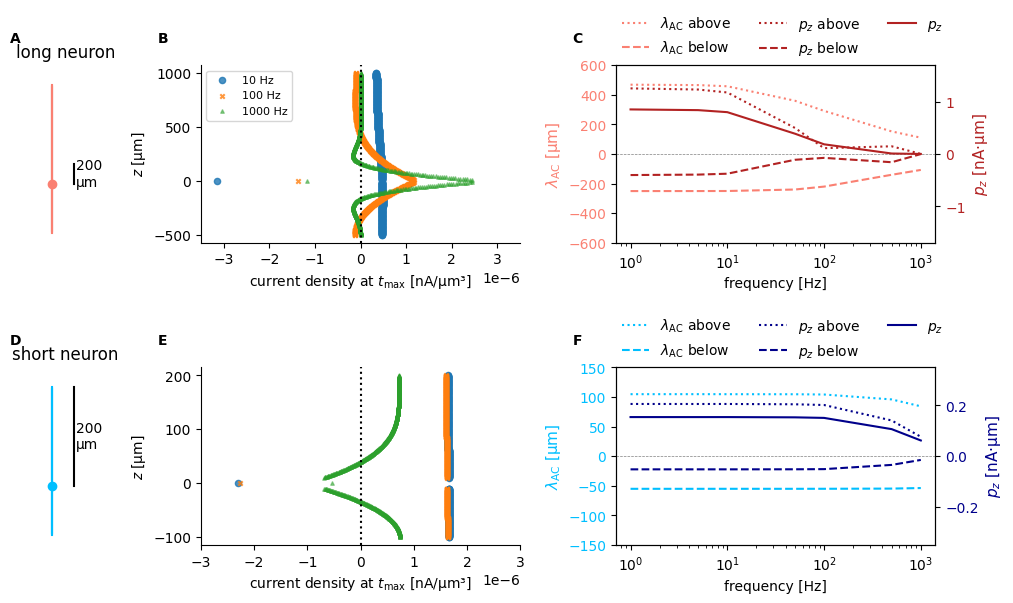

In [13]:

color_neurons = {
    'BL_-500_UL_1000_SD_20_DD_2': 'salmon',
    'BL_-100_UL_200_SD_20_DD_2': 'deepskyblue',
    'BL_-200_UL_1000_SD_20_DD_2': 'salmon',
    'BL_-50_UL_200_SD_20_DD_2': 'deepskyblue'
}

cell_short_names = {
    'BL_-500_UL_1000_SD_20_DD_2': 'long neuron',
    'BL_-100_UL_200_SD_20_DD_2': 'short neuron',
    'BL_-200_UL_1000_SD_20_DD_2': 'long neuron',
    'BL_-50_UL_200_SD_20_DD_2': 'short neuron',
}

cell_cdm_colors = {
    'BL_-500_UL_1000_SD_20_DD_2': 'firebrick',
    'BL_-100_UL_200_SD_20_DD_2': 'darkblue',
    'BL_-200_UL_1000_SD_20_DD_2': 'firebrick',
    'BL_-50_UL_200_SD_20_DD_2': 'darkblue',
}

cell_cdm_up_down_colors = {
    'BL_-500_UL_1000_SD_20_DD_2': 'firebrick',
    'BL_-100_UL_200_SD_20_DD_2': 'darkblue',
    'BL_-200_UL_1000_SD_20_DD_2': 'firebrick',
    'BL_-50_UL_200_SD_20_DD_2': 'darkblue',
}

sim_type = "shorter"
sim_type = "longer"

if sim_type == "shorter":
    cell_names = ['BL_-200_UL_1000_SD_20_DD_2', 'BL_-50_UL_200_SD_20_DD_2']
else:
    cell_names = ['BL_-500_UL_1000_SD_20_DD_2', 'BL_-100_UL_200_SD_20_DD_2', ]

cell_xlims_left = {"BL_-100_UL_200_SD_20_DD_2": [-0.3e-5, 0.3e-5],
                   'BL_-50_UL_200_SD_20_DD_2': [-0.25e-5, 0.25e-5],
                   'BL_-200_UL_1000_SD_20_DD_2': [-0.35e-5, 0.35e-5],
                   'BL_-500_UL_1000_SD_20_DD_2': [-0.35e-5, 0.35e-5]
                   }

# cell_xlims_right = {"BL_-100_UL_200_SD_20_DD_2": [-2e-6, 6e-6],
#                    'BL_-500_UL_1000_SD_20_DD_2': [-10e-6, 30e-6],
#                     "BL_-50_UL_200_SD_20_DD_2": [-1e-6, 3e-6],
#                     'BL_-200_UL_1000_SD_20_DD_2': [-0.1e-5, 0.2e-5]
#                     }

pz_ylims = {"BL_-100_UL_200_SD_20_DD_2": [-0.35, 0.35],
                   'BL_-500_UL_1000_SD_20_DD_2': [-1.7, 1.7],
                    "BL_-50_UL_200_SD_20_DD_2": [-0.3, 0.3],
                    'BL_-200_UL_1000_SD_20_DD_2': [-1.6, 1.6]
                    }

lambda_ylims = {"BL_-100_UL_200_SD_20_DD_2": [-150, 150],
                   'BL_-500_UL_1000_SD_20_DD_2': [-600, 600],
                    "BL_-50_UL_200_SD_20_DD_2": [-100, 100],
                    'BL_-200_UL_1000_SD_20_DD_2': [-500, 500]
                    }

plot_freqs = [10, 100, 1000]

# ---- Sub-panels: morphology + two-axis scatter ----
left_ratio = 1.9
middle_ratio = 0.6
right_ratio = 1.2

fig = plt.figure(figsize=(10, 6))
fig.subplots_adjust(left=0.02, right=0.93, bottom=0.10, top=0.9)

gs = gridspec.GridSpec(2, 3, width_ratios=[0.5, 2, 2],
                       height_ratios=[1, 1],
                       wspace=0.4, hspace=0.7)

for row_idx, cell_name in enumerate(cell_names):
    freqs = np.array(imem_data[cell_name]["freqs"])
    print(freqs)
    pz_amps = np.array(imem_data[cell_name]['cdm'])
    pz_phases = np.array(imem_data[cell_name]['cdm_phases'])
    pz_pos_amps = np.array(imem_data[cell_name]['cdm_pos'])
    pz_neg_amps = np.array(imem_data[cell_name]['cdm_neg'])
    pz_pos_phases = np.array(imem_data[cell_name]['cdm_pos_phases'])
    pz_neg_phases = np.array(imem_data[cell_name]['cdm_neg_phases'])

    positive_avrg_imem_pos = np.array(imem_data[cell_name]['positive_avg_imem_pos'])
    negative_avrg_imem_pos = np.array(imem_data[cell_name]['negative_avg_imem_pos'])

    input_phases = imem_data[cell_name]['input_phases']
    input_amps = imem_data[cell_name]['input_amps']

    im_amps = np.array(imem_data[cell_name]['imem_amps'])
    im_phases = np.array(imem_data[cell_name]['imem_phases'])

    x = np.array(imem_data[cell_name]['x'])
    z = np.array(imem_data[cell_name]['z'])
    area = np.array(imem_data[cell_name]['area'])

    zs = np.array(imem_data[cell_name]['z']).mean(axis=1)
    mask = zs != 0

    cell_clr = color_neurons[cell_name]

    ax_m = fig.add_subplot(gs[row_idx, 0], xlim=[np.min(z) * 1.2, np.max(z) * 1.2], frameon=False,
                           xticks=[], yticks=[], ylim=[np.min(z) * 1.2, np.max(z) * 1.2],
                           title=cell_short_names[cell_name])
    ax_m.plot([-np.min(z), -np.min(z)], [0, 200], c='k', clip_on=False)
    ax_m.text(-np.min(z)*1.1, 100, "200 \nµm", ha='left', va="center", clip_on=False)
    ax_m.plot(x.T, z.T, c=cell_clr)
    ax_m.plot(x[0].mean(), z[0].mean(), 'o', c=cell_clr)

    ax_left = fig.add_subplot(gs[row_idx, 1], xlabel=r"current density at $t_{\rm max}$ [nA/µm³]")

    #ax_right = fig.add_subplot(2, 6, row_idx * 6 + 4, sharey=ax_left)

       # --- Axis settings ---
    ax_left.axvline(0, color='black', linestyle=':')
    #ax_right.axvline(0, color='black', linestyle=':')
    # Hide ticks/spines
    #ax_right.yaxis.set_visible(False)
    #ax_right.spines['left'].set_visible(False)
    # ax_left.spines['right'].set_visible(False)

    # Add diagonal breaks
    # d = 0.015
    # kwargs = dict(transform=ax_left.transAxes, color='k', clip_on=False)
    # ax_left.plot([1-d*middle_ratio/left_ratio, 1+d*middle_ratio/left_ratio], [-d, +d], **kwargs)
    # ax_left.plot([1-d*middle_ratio/left_ratio, 1+d*middle_ratio/left_ratio], [1-d, 1+d], **kwargs)

    # kwargs.update(transform=ax_right.transAxes)
    # ax_right.plot([-d*middle_ratio/right_ratio, +d*middle_ratio/right_ratio], [-d, +d], **kwargs)
    # ax_right.plot([-d*middle_ratio/right_ratio, +d*middle_ratio/right_ratio], [1-d, 1+d], **kwargs)

    # x-ticks on scatterplot
    # fmt_left = ScalarFormatter(useMathText=True)
    # fmt_left.set_powerlimits((-2, 2))
    # ax_left.ticklabel_format(style='sci', axis='x', scilimits=(-2, 2))
    # ax_left.xaxis.set_major_formatter(fmt_left)
    # ax_left.tick_params(axis='x', labelsize=7)

    # fmt_right = ScalarFormatter(useMathText=True)
    # fmt_right.set_powerlimits((-2, 2))
    # ax_right.ticklabel_format(style='sci', axis='x', scilimits=(-2, 2))
    # ax_right.xaxis.set_major_formatter(fmt_right)
    # ax_right.tick_params(axis='x', labelsize=7)

    ax_left.set_ylabel('$z$ [µm]', fontsize=10)

    ax_freq_lambd = fig.add_subplot(gs[row_idx, 2], xlabel="frequency [Hz]")
    ax_freq_pz = ax_freq_lambd.twinx()

    ax_freq_pz.set_ylim(pz_ylims[cell_name])
    ax_freq_lambd.set_ylim(lambda_ylims[cell_name])
    ax_freq_pz.axhline(0, ls='--', lw=0.5, c='gray')


    xlim_left = cell_xlims_left[cell_name]
    #xlim_right = cell_xlims_right[cell_name]

    ax_left.set_xlim(xlim_left)
    # ax_right.set_xlim(xlim_right)

    pz_values = np.zeros(len(freqs))
    pz_pos_values = np.zeros(len(freqs))
    pz_neg_values = np.zeros(len(freqs))
    lines = []
    line_names = []
    for idx, freq in enumerate(freqs):

        f_idx = np.argmin(np.abs(freqs - freq))

        T = 1 / freq * 1000 * 1
        t_ = np.linspace(0, T, 100)

        im_amp = im_amps[:, f_idx]
        input_amp = input_amps[f_idx]
        pz_amp = pz_amps[f_idx]
        pz_pos_amp = pz_pos_amps[f_idx]
        pz_neg_amp = pz_neg_amps[f_idx]

        print(f"{cell_name} pz at {freq} Hz: {pz_amp}")
        imem_pos_neg = negative_avrg_imem_pos[f_idx]
        imem_pos_pos = positive_avrg_imem_pos[f_idx]

        input_phase = input_phases[f_idx]
        pz_phase = pz_phases[f_idx] - input_phase
        pz_pos_phase = pz_pos_phases[f_idx] - input_phase
        pz_neg_phase = pz_neg_phases[f_idx] - input_phase
        im_phase = im_phases[:, f_idx] - input_phase
        input_phase -= input_phase

        pz = pz_amp * np.sin(2 * np.pi * freq * t_ / 1000 + pz_phase)
        pz_pos = pz_pos_amp * np.sin(2 * np.pi * freq * t_ / 1000 + pz_pos_phase)
        pz_neg = pz_neg_amp * np.sin(2 * np.pi * freq * t_ / 1000 + pz_neg_phase)
        input_current = input_amp  * np.sin(2 * np.pi * freq * t_ / 1000 + input_phase)

        t_pz_max_idx = np.argmax(pz)
        t_pz_max = t_[t_pz_max_idx]

        im = np.array([im_amp[c_idx] * np.sin(2 * np.pi * freq * t_ / 1000 + im_phase[c_idx])
                       for c_idx in range(im_amp.shape[0])])
        im_soma = im[0, :].copy()

        im_t_max = im[:, t_pz_max_idx]
        if im_soma[t_pz_max_idx] > 0:
            im_t_max *= -1

        pz_values[idx] = pz[t_pz_max_idx]
        pz_pos_values[idx] = pz_pos[t_pz_max_idx]
        pz_neg_values[idx] = pz_neg[t_pz_max_idx]

        fig_ctrl = plt.figure(figsize=[10, 4])
        ax_stim = fig_ctrl.add_subplot(3, 1, 1)
        ax_im = fig_ctrl.add_subplot(3, 1, 2)
        ax_pz = fig_ctrl.add_subplot(3, 1, 3)

        ax_stim.plot(t_, input_current, c='k')
        ax_im.plot(t_, im_soma / np.std(im_soma), c='b', ls=':')
        l1, = ax_pz.plot(t_, pz / np.std(pz), c=cell_cdm_colors[cell_name], ls='-')
        l2, = ax_pz.plot(t_, pz_pos / np.std(pz_pos), c=cell_cdm_colors[cell_name], ls=':')
        l3, = ax_pz.plot(t_, pz_neg / np.std(pz_neg), c=cell_cdm_colors[cell_name], ls='--')
        ax_pz.legend([l1, l2, l3], ["$p_z$", "$p_z$ above", "$p_z$ below"])

        ax_stim.axvline(t_pz_max, ls='--', c='gray')
        ax_im.axvline(t_pz_max, ls='--', c='gray')
        ax_pz.axvline(t_pz_max, ls='--', c='gray')
        fig_ctrl.savefig(f"ctrl_{cell_name}_{freq}Hz.png", dpi=300)
        plt.close(fig_ctrl)

        # Marker styling unchanged
        if freq == 10:
            marker, size, alpha = 'o', 20, 0.8
        elif freq == 100:
            marker, size, alpha = 'x', 10, 0.8
        else:
            marker, size, alpha = '^', 6, 0.5

        colors = ["tab:blue", "tab:orange", "tab:green"]
        if freq in plot_freqs:
            f_idx_ = np.argmin(np.abs(freq - plot_freqs))
            clr = colors[f_idx_]
            print(f_idx_, clr)
            l = ax_left.scatter(im_t_max / area, zs, marker=marker, s=size, alpha=alpha, c=clr)
            # ax_right.scatter(im_t_max / area, zs, marker=marker, s=size, alpha=alpha)
            lines.append(l)
            line_names.append(f"{freq} Hz")
        #xlim_left = [np.min(im_t_max), np.min(im_t_max) / 2]
        #xlim_right = [np.min([np.min(im_t_max[mask]), 0]), np.max(im_t_max) * 1.2]

    if row_idx == 0:
        ax_left.legend(lines, line_names, loc='upper left', fontsize=8)

    l1, = ax_freq_pz.semilogx(freqs, pz_values, color=cell_cdm_colors[cell_name], ls='-')
    l2, = ax_freq_pz.semilogx(freqs, np.abs(pz_pos_values), color=cell_cdm_colors[cell_name], ls=':')
    l3, = ax_freq_pz.semilogx(freqs, -np.abs(pz_neg_values), color=cell_cdm_colors[cell_name], ls='--')

    l1_, = ax_freq_lambd.semilogx(freqs, positive_avrg_imem_pos, c=cell_clr, ls=':')
    l2_, = ax_freq_lambd.semilogx(freqs, negative_avrg_imem_pos, c=cell_clr, ls='--')

    #ax_freq_lambd.legend([l1_, l2_], [r'$\lambda_{\rm AC}$ above', r'$\lambda_{\rm AC}$ below'])
    ax_freq_pz.legend([ l1_, l2_, l2, l3, l1,],
                      [r'$\lambda_{\rm AC}$ above', r'$\lambda_{\rm AC}$ below', "$p_z$ above", "$p_z$ below","$p_z$" ],
                      ncol=3, frameon=False, loc=(0, 1.01))

    ax_freq_lambd.set_ylabel(r'$\lambda_{\rm AC}$ [µm]', fontsize=11, color=cell_clr)
    ax_freq_lambd.tick_params(axis='y', labelcolor=cell_clr)
    ax_freq_pz.set_ylabel(r'$p_z$ [nA·µm]', fontsize=11, color = cell_cdm_colors[cell_name])
    ax_freq_pz.tick_params(axis='y', labelcolor=cell_cdm_colors[cell_name])

    pc.simplify_axes(ax_left)
    #ax_m.set_ylim(ax_m.get_ylim())
    #ax_left.set_ylim(ax_m.get_ylim())
    #print(ax_m.get_ylim())
    #print(ax_left.get_ylim())
    pc.mark_subplots([ax_m, ax_left, ax_freq_pz], [["A", "B", "C"], ["D", "E", "F"]][row_idx])

fig.savefig(f"fig6_alt.pdf")


In [27]:
freqs

[5, 10, 50, 100, 500, 1000]